# Phase 0 : Use Case

## Cas d’usage : Estimation automatique du prix de vente pour une plateforme immobilière en ligne

### Problème métier

L’objectif principal de notre plateforme est de permettre à un **propriétaire particulier** souhaitant vendre son bien de connaître immédiatement une **estimation objective de son prix**. Cette estimation permet :

* D’instaurer **confiance** chez le vendeur.
* De **réduire les délais de vente** en affichant un prix réaliste dès le départ.
* D’**automatiser** le processus pour limiter la mobilisation de ressources humaines coûteuses.

Dans ce cadre, nous intégrons un **modèle de machine learning** directement dans notre interface, permettant à l’utilisateur d’obtenir une **estimation instantanée** dès qu’il renseigne les caractéristiques de son bien.

---

## Coûts d'une mauvaise prédiction

* **Sous-estimation** : perte financière pour le vendeur (prix trop bas)
* **Sur-estimation** : allongement du délai de vente, perte d’opportunité
* **Gain** : estimation juste → vente rapide → satisfaction client + meilleure image

---

## Objectifs business et KPIs

| Objectif                    | Description                                           | KPI cible                                      |
| --------------------------- | ----------------------------------------------------- | ---------------------------------------------- |
| Réduire les délais de vente | Positionner correctement le prix dès la mise en ligne | –20 % de délai moyen (passer de 60 à 48 jours) |
| Générer des leads           | Attirer des propriétaires via l’outil gratuit         | +30 % d’utilisateurs actifs/mois               |
| Augmenter la satisfaction   | Fiabilité et rapidité de l’estimation                 | Score CSAT ≥ 4,5/5                             |
| Limiter les erreurs         | Minimiser l’écart entre prix estimé et réel           | RMSE ≤ 20 000 € et RMSLE ≤ 0,15                |

---

## Fréquence de mise à jour & workflow

1. **Ré-entraînement mensuel** sur nouvelles ventes (pipeline automatique).
2. **Suivi hebdomadaire** des indicateurs :

   * Drift des variables clés (ex. prix moyen/m²)
   * Écart moyen estimé vs. prix réalisé
3. **Alerte** si RMSE dépasse 25'000 € ou si dérive > 10 %
4. **Feedback utilisateur** via sondage post-vente pour ajuster les features

---

## Rôle des données

Le jeu de données Kaggle *House Prices: Advanced Regression Techniques* constitue une base réaliste pour construire ce système :

* **79 variables descriptives** (superficie, nombre de pièces, quartier, qualité des matériaux, etc.) et un prix de vente final.
* **Échantillonnage** : split train/test 80 % / 20 % pour évaluation hors-sample.
* **Holdout ratio** envisagé : 80/20 pour valider les performances avant soumission sur Kaggle.

Ces données seront utilisées pour entraîner notre modèle à **prédire un prix à partir de caractéristiques connues**. Pour rester fiable, le modèle sera mis à jour régulièrement avec **de nouvelles ventes enregistrées** sur la plateforme.

---

## Acteurs concernés

1. **Vendeurs particuliers**

   * Utilisent l’outil pour obtenir une estimation fiable et gratuite.
   * Décident ensuite de mettre leur bien en ligne avec plus de sérénité.

2. **Plateforme**

   * Propose une **expérience utilisateur innovante**.
   * Génère des leads qualifiés via l’usage de l’outil d’estimation.
   * Réduit les allers-retours de négociation.

3. **Équipe Data Science**

   * Conçoit, teste, valide et surveille le modèle.
   * S’appuie sur le cycle **CRISP-ML** pour garantir la robustesse et l’évolutivité du système.

---

## Intégration du modèle dans le processus métier

* **Avant** : le vendeur doit consulter un agent ou faire une estimation manuelle via comparaison ou intuition.
* **Après** : en quelques clics, il renseigne les informations sur son bien et obtient une **fourchette de prix automatisée** (ex. : « entre 260'000 € et 280'000 € »).

Cela améliore l’expérience client, limite les frictions et **valorise la data comme avantage compétitif**.

---

## Approche ML envisagée

1. **Modèles testés** : Régressions (linéaire, Lasso, Ridge), Arbres de décision, Random Forest, Gradient Boosting, XGBoost.
2. **Pipeline** : Nettoyage, encodage, normalisation, sélection de features.
3. **Évaluation** : RMSE, RMSLE (recommandé pour ce challenge).
4. **Validation croisée** : K-Fold pour limiter l’overfitting.
5. **Hyperparamètres** : Grid Search, Random Search ou méthode bayésienne selon le modèle.

---

## Étapes CRISP-ML suivies

| Phase                  | Action                                                                                                   |
| ---------------------- |----------------------------------------------------------------------------------------------------------|
| **Idéation**           | Compréhension du problème métier et de l’opportunité commerciale.                                        |
| **Data Understanding** | Exploration des variables les plus informatives (ex. quartier, superficie, qualité).                     |
| **Design**             | Création d’un pipeline sklearn prêt à transformer `train.csv` et `test.csv`.                             |
| **Model Engineering**  | Test de plusieurs modèles et tuning des hyperparamètres.                                                 |
| **Evaluation**         | Sélection du meilleur modèle pour la plateforme, interprétation métier.                                  |
| **Operation**          | Soumission sur Kaggle, puis intégration dans la plateforme avec monitoring, MLOps et contrôle de dérive. |

---

## ML Canvas (v0.1)

![ML Canvas v0.1 : résumé des tâches, données, décisions, métriques](v0.1-MLCanevas.png)

---

## Conclusion

Notre use case illustre une **application concrète du machine learning au service du business**. Grâce à l’outil d’estimation :

* Le vendeur bénéficie d’un service rapide, fiable et rassurant.
* La plateforme optimise son acquisition client et ses performances internes.
* Le modèle peut évoluer avec les tendances du marché et rester pertinent.


# Phase 1 : Phase d'idéation

## 1.1 Analyse du besoin métier et préparation des données

La mise en place d'un modèle d'estimation immobilière pour une plateforme en ligne implique d’abord une étape préliminaire cruciale consistant à préciser les attentes commerciales, à identifier précisément les indicateurs de performance du modèle, et à vérifier rigoureusement la qualité et la pertinence des données disponibles.

Dans ce contexte précis, cette étape garantit que notre solution automatisée répondra aux exigences des utilisateurs en fournissant une évaluation immobilière immédiate et objective. Elle permet également de confirmer que les informations récoltées via notre formulaire en ligne sont suffisamment qualitatives pour construire un modèle prédictif robuste et pertinent pour nos utilisateurs particuliers.


In [1]:
# !pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# TODO : supprimer confusion_matrix , classification_report et accuracy_score ? -> on travaill en régression

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.graphics.gofplots import ProbPlot

import math

In [3]:
plt.style.use('seaborn-v0_8')

# chargement des données
train_raw = pd.read_csv('Data/train.csv', index_col = 'Id')
validation_raw = pd.read_csv('Data/test.csv', index_col = 'Id')
test_raw = validation_raw # pas envie de redéfinir toutes les variables ...


# aperçu initial
train_raw.info()
train_raw.isna().sum()
train_raw.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 1.1.1 Aperçu des données

In [4]:
train_raw.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### 1.1.1.4 Identification de la cible du modèle

Lorsqu’on débute une analyse prédictive, il est essentiel de comprendre précisément la variable à prédire. Dans notre cas, il s'agit du montant auquel un bien immobilier sera vendu, désigné par la variable **SalePrice**.

Pour répondre spécifiquement au besoin, notre modèle exploitera diverses caractéristiques immobilières telles que la superficie, la qualité des matériaux ou encore l’emplacement, afin de prévoir précisément cette valeur finale.

In [5]:
# descriptive statistics summary
train_raw['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Ce résumé chiffré ne permet pas une interprétabilité visuelle directe, mais indique néanmoins que la majorité des biens sont vendus dans une fourchette de prix assez resserrée : environ 130 000 pour le premier quartile, une médiane à 163 000, une moyenne à 180 000 et un troisième quartile autour de 214 000. Cette différence entre médiane et moyenne révèle la présence de quelques biens particulièrement coûteux, qui influencent la moyenne vers des valeurs supérieures.

Ce type de situation est fréquent dans l'immobilier, où un grand nombre de biens se concentrent dans une tranche de prix moyenne, tandis que quelques propriétés d’exception font nettement grimper la moyenne.

#### 1.1.1.5 Visualisation de la distribution de la variable cible

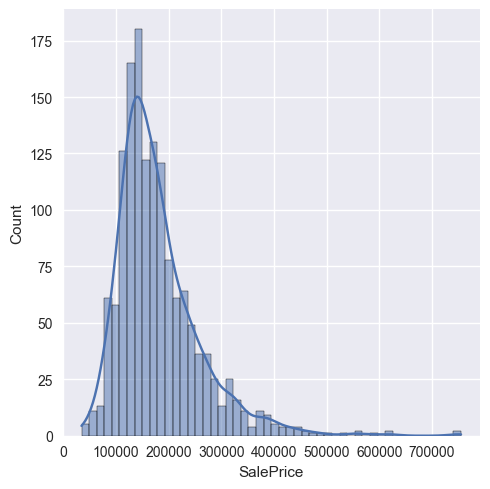

In [6]:
# distribution plot with normal fit
ax = sns.displot(data = train_raw['SalePrice'], kde=True, bins=50)
plt.show()

La distribution observée présente clairement une asymétrie marquée. Afin de confirmer statistiquement qu'elle diffère d'une distribution normale, un test d’hypothèse rapide doit être réalisé.

Dans notre scénario, l'hypothèse initiale suppose que la variable **Prix de vente** suit une distribution normale dans la population d’origine. Pour vérifier cette hypothèse, nous allons recourir au *test statistique de Shapiro-Wilk* qui, en cas de rejet, validera que les données ne sont pas distribuées normalement.

The assocated p-value is : 3.2061412312022114e-33
With a threshold α = 0.05, we reject the null hypothesis


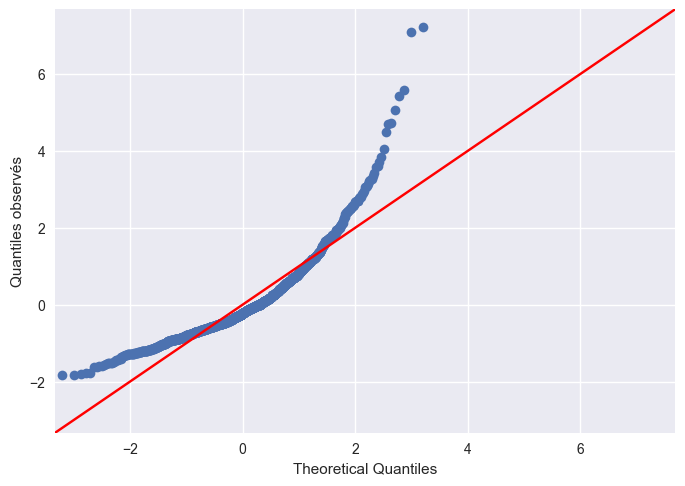

In [7]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha :
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else :
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')

qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.ylabel("Quantiles observés")
plt.show()

Le résultat du *test de Shapiro-Wilk* et l’analyse du **Q-Q plot** indiquent clairement que les données ne suivent pas une distribution normale. Ce constat appuie la nécessité de transformer la variable cible via une échelle logarithmique. Cette opération permet de régulariser la dispersion des valeurs et réduit l’impact disproportionné des propriétés très coûteuses sur le modèle.

#### 1.1.1.6 Transformation logarithmique de la variable cible

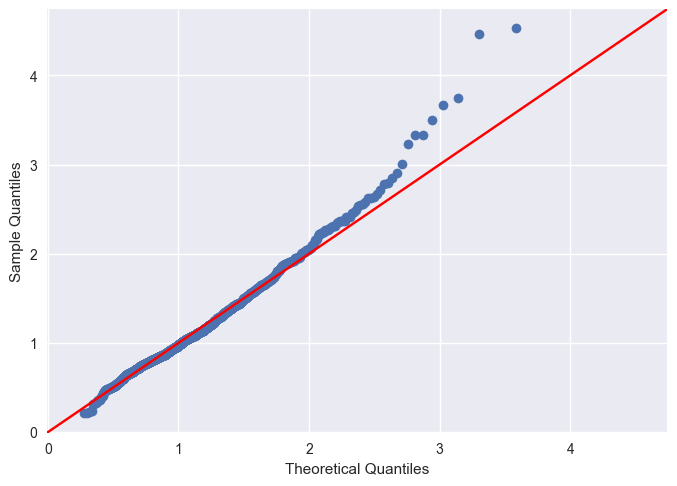

In [8]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

#### 1.1.1.7 Réduction de l’influence des valeurs extrêmes par log-transformation

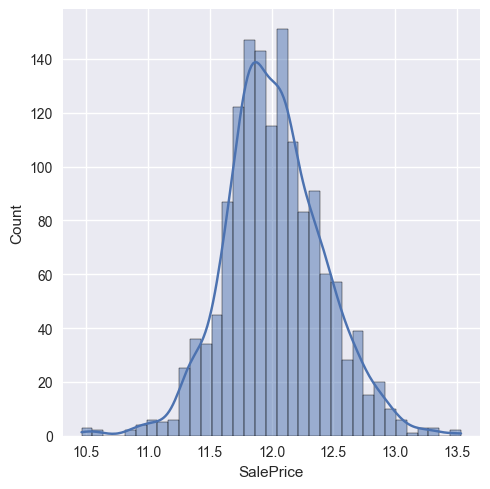

In [9]:
# new variable target which is the logarithm of the SalePrice
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

L'histogramme de la variable **SalePrice** après l'utilisation du logarithme `log1p`est proche d'une courbe normale. La forme est désormais symétrique et centré autour d'un pic (vers 12). Et le logarithme a permis une réduction de l'influence des valeurs extrêmes.

### 1.1.2 Variables indépendantes

Le jeu de données comporte trois catégories de variables explicatives, dont le rôle et la nature diffèrent en termes d’information véhiculée et de traitement statistique. Les variables qualitatives codent des caractéristiques catégorielles de chaque propriété : elles décrivent l’environnement (quartier, accès, aménagements) ainsi que des attributs constructifs (type de toiture, matériaux extérieurs, présence ou non d’équipements). Ces modalités, parfois ordinales (qualité, conditions) ou nominales (type de maison, revêtement), devront être converties en variables indicatrices ou ordonnées selon leur hiérarchie intrinsèque.

Les variables quantitatives mesurent des grandeurs continues ou discrètes relatives aux dimensions et à la qualité des matériaux : surfaces de terrain et de plancher, nombre de pièces ou de commodités, évaluation subjective chiffrée de la qualité générale. Leur distribution, souvent asymétrique et sujette à des valeurs extrêmes, nécessitera des transformations appropriées (logarithmisation, normalisation) pour stabiliser la variance et maximiser la linéarité vis-à-vis de la cible.

Enfin, les variables temporelles documentent les dates de construction, de rénovation et de vente. Plutôt que d’interpréter directement l’année, il est préférable de calculer des âges relatifs (âge de la maison, époque de la dernière rénovation, vieillissement du garage) afin de capturer l’évolution temporelle de la valeur. Ces nouveaux indicateurs temporels éclaireront l’effet de l’ancienneté et de l’entretien sur le prix.

In [10]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish',
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

# problème de noms de variable - simplification
date_cols = date 

### 1.1.3 Fusion des jeux d’entraînement et de test pour un nettoyage unifié
La concaténation des jeux d’entraînement et de validation au sein d’un seul DataFrame constitue une étape cruciale pour garantir l’homogénéité du prétraitement. En regroupant `train_raw` et `validation_raw`, toutes les opérations suivantes (imputation des valeurs manquantes, encodage des variables catégorielles, standardisation des variables numériques, calcul des âges à partir des dates brutes) seront appliquées de manière identique, ce qui évite les décalages de format ou les divergences de dimension entre les deux ensembles. Cette stratégie permet également de s’assurer que la création de nouvelles variables – notamment les indicateurs temporo-qualitatifs – intègre l’ensemble de la variabilité observée, sans qu’un lot soit considéré isolément. Une fois le nettoyage unifié réalisé, il sera aisé de reconstituer les sous-ensembles d’entraînement et de validation en scindant `data_raw` selon la présence ou non de la cible, tout en conservant l’intégrité des transformations appliquées.

In [11]:
data_raw = pd.concat([train_raw, validation_raw], axis=0)

### 1.2 Imputation des valeurs manquantes

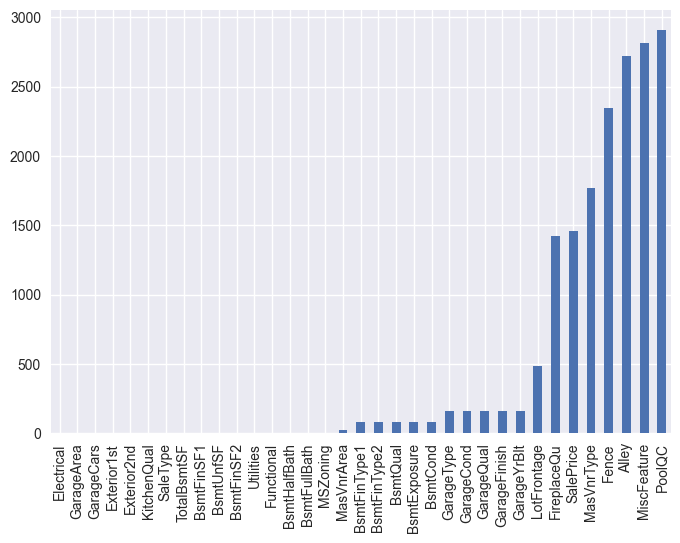

In [12]:
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]

    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()

        plt.show()

plot_missing(data_raw)

La visualisation de la quantité de valeurs manquantes révèle une différence marquée entre les biens déjà vendus et ceux en cours d’évaluation ; le jeu de test présente systématiquement davantage d’informations manquantes, illustré notamment par la variable **TotalBsmtSF**, qui est exhaustive dans le jeu d’entraînement mais partiellement renseignée dans le jeu de test. Cette asymétrie reflète la réalité du processus métier : les transactions clôturées font l’objet d’un dossier complet, tandis que les estimations prospectives reposent sur des relevés parfois incomplets. Avant toute modélisation, il est donc impératif de comprendre non seulement l’étendue des données manquantes, mais également leur origine et leur signification : une absence de **PoolQC** ou de **Alley** renvoie souvent à l’absence physique de ces équipements, tandis que des manques sur **LotFrontage** ou **MasVnrArea** peuvent traduire un défaut de mesure ou de déclaration.

Pour garantir la cohérence du prétraitement, nous adopterons une stratégie d’imputation adaptée à chaque nature de variable et soutenue par la connaissance métier. Les variables indiquant la présence ou l’absence d’un équipement (ex. **PoolQC**, **FireplaceQu**) seront remplies par une modalité explicite « Absent », évitant ainsi de confondre un manque technique avec une modalité légitime. Les variables quantitatives, souvent asymétriques et sujettes à des valeurs extrêmes, feront l’objet d’une imputation conditionnée : une estimation par la médiane permettra de limiter l’impact des outliers, tandis que certaines dimensions purement structurelles (ex. **GarageYrBlt**) seront comblées par une valeur de remplacement logique (année de construction principale) pour conserver un sens physique. Enfin, la création de variables indicatrices de non-observation pourra être envisagée pour capturer tout effet de signalement ou de biais introduit par les données manquantes elles-mêmes. Cette approche homogène, appliquée simultanément aux deux sous-ensembles regroupés, assurera la reproductibilité et la robustesse du modèle lors de son déploiement opérationnel.

### 1.2.1 Variables quantitatives

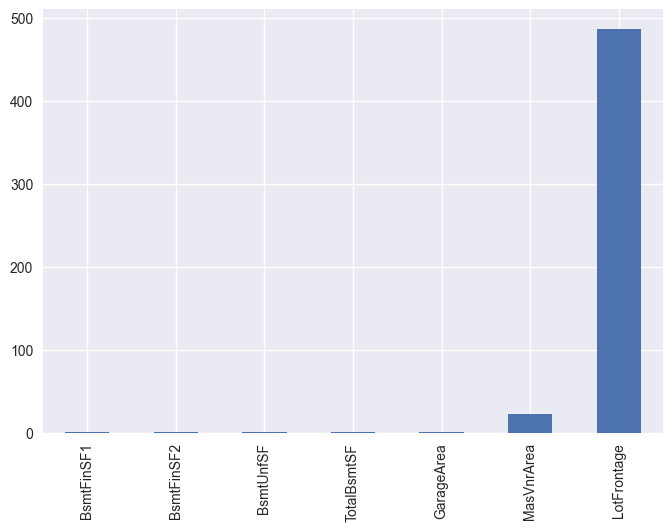

In [13]:
# Affichage des variables manquantes
plot_missing(data_raw[quantitative])

L’appel initial à `plot_missing(data_raw[quantitative])` permet de visualiser l’étendue et la répartition des valeurs absentes au sein des variables numériques : on y constate que l’absence de valeur coïncide systématiquement avec l’inexistence de l’élément (garage, sous-sol, piscine, etc.). Dès lors, il paraît scientifiquement justifié de remplacer ces `NaN` par zéro, car une surface non renseignée traduit ici une surface nulle plutôt qu’un défaut de mesure isolé.

La fonction `fill_missing_with_constant` procède à une copie du jeu de données, puis, pour chaque variable quantitative présentant des manques, elle substitue la constante spécifiée (ici 0) à toutes les occurrences de `NaN`. Ce choix garantit que l’on préserve l’interprétabilité physique de chaque mesure : un garage inexistant aura une surface à zéro, un sous-sol non aménagé ne contribue pas à la surface habitable. Par ailleurs, cette imputation uniforme facilite la standardisation ultérieure et prévient l’introduction de biais liés à des méthodes d’imputation plus complexes, moins adaptées lorsque l’absence vaut signification.


In [14]:
# Pour les variables quantitatives, nous allons remplir les colonnes avec 0
def fill_missing_with_constant(data, columns, constant):

    data_clean = data.copy()

    for c in columns :

        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)

    return data_clean

### 1.2.2 Variables qualitatives asdf

L’analyse de la carte des valeurs manquantes pour les variables qualitatives révèle que l’essentiel des `NaN` correspond à l’absence d’un équipement ou d’une caractéristique (ex. pas de piscine, de ruelle ou de parement en parement de briques). Plutôt que de les traiter comme de simples données manquantes, il est préférable d’en faire une modalité à part entière : l’affectation d’une étiquette explicite « NA » garantit que l’on distingue clairement l’absence (ou l’inapplicabilité) d’un attribut d’une difficulté de relevé ou d’une erreur de saisie. Cette stratégie reflète la préférence de conserver la traçabilité de l’omission plutôt que de la masquer derrière une valeur générique comme la plus fréquente.

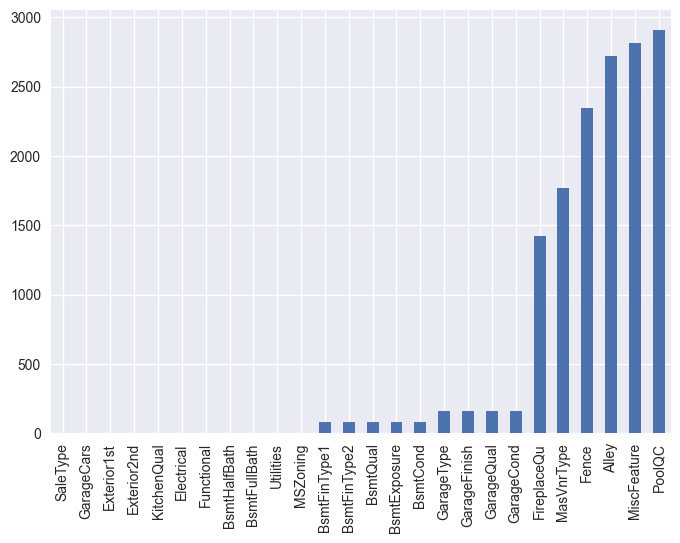

In [15]:
plot_missing(data_raw[qualitative])

En pratique, nous exploitons la fonction `fill_missing_with_constant` définie précédemment en lui passant, pour chaque variable qualitative présentant des `NaN`, la constante `'NA'`. Cette méthode assure une cohérence de traitement identique à l’ensemble des variables catégorielles et prépare parfaitement le terrain pour un encodage one‐hot ou ordinal ultérieur, sans risque de biais induit par une répartition artificielle des modalités manquantes. Dès lors, la structure du DataFrame reste homogène, et l’interprétation des coefficients de modèle ou la visualisation des effets de chaque modalité restent limpides, y compris pour celles correspondant à l’absence d’équipement.

### 1.2.3 Variables temporelles

La visualisation des données manquantes met en évidence que, parmi les variables temporelles, **GarageYrBlt** est la seule à présenter des valeurs absentes, ce qui s’explique logiquement par l’absence de garage pour certains biens. D’un point de vue métier, il est pertinent de substituer ces dates manquantes par l’année de construction principale (`YearBuilt`), car l’édification du garage coïncide en général avec celle de la maison et reflète un âge similaire de la structure. La fonction `fill_missing_with_column` réalise cette opération en dupliquant la valeur de `YearBuilt` là où `GarageYrBlt` est null ; cette méthode préserve la cohérence temporelle tout en évitant d’introduire une modalité “inconnue” qui n’aurait pas de sens physique. À l’issue de cette étape, il sera possible de calculer de nouveaux indicateurs d’ancienneté (âge du garage, âge global de la bâtisse) sans craindre de ruptures dans la série temporelle ni de biais imputables à des valeurs aberrantes.

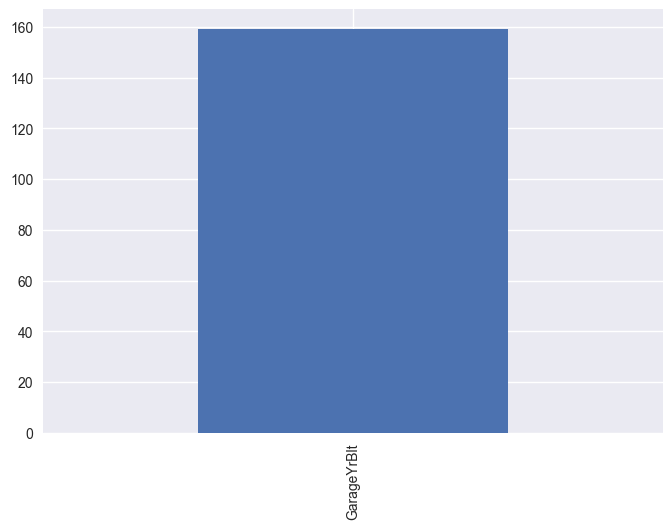

In [16]:
plot_missing(data_raw[date])

In [17]:
# Pour les variables temporelles, nous allons remplir les valeurs manquantes en utilisant les valeurs d'une autre colonne
def fill_missing_with_column(data, missing, column) :

    data_clean = data.copy()

    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])

    return data_clean

## 1.3 Transformation de base

La transformation temporelle proposée s’inscrit dans une démarche de caractérisation de l’effet de l’ancienneté sur la valeur des biens. Plutôt que de conserver les années brutes de construction, de rénovation et d’installation du garage, il est préférable de les traduire en durées écoulées entre ces événements et la date de vente (`YrSold`). Ces nouvelles variables d’âge : âge initial de la construction, délai depuis la dernière rénovation et ancienneté du garage ; permettent de mesurer directement l’impact du vieillissement, de l’usure et des interventions d’entretien sur le prix. Cette approche améliore la linéarité vis-à-vis de la variable cible, facilite l’interprétation des coefficients (une année supplémentaire de vieillissement se traduit par Δ en prix) et rend explicite la dynamique temporelle inhérente à l’évaluation immobilière.

In [18]:
def compute_differences_to_year_sold(data) :

    data_clean = data.copy()

    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']

    return data_clean

## 1.4 Exécution du processus de nettoyage

La fonction `clean` orchestre l’ensemble des opérations de prétraitement définies précédemment : elle applique d’abord l’imputation ciblée des variables numériques (remplacement des `NaN` par zéro) et catégorielles (modalité « NA »), puis comble les lacunes temporelles du garage en reprenant l’année de construction principale. Elle enchaîne ensuite la transformation des dates brutes en durées écoulées jusqu’à la vente, générant des indicateurs d’ancienneté exploitables directement par les modèles. L’appel à `clean(data_raw)` aboutit ainsi à un DataFrame unifié, débarrassé de toutes valeurs manquantes et doté de variables interprétables, prêt pour la suite du pipeline (feature engineering et modélisation).


In [19]:
def clean(data) :

    data_clean = data.copy()

    # imputing missing variables
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # transform date columns
    data_clean = compute_differences_to_year_sold(data_clean)

    return data_clean

data_clean = clean(data_raw)

data_clean.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0


## 1.5 Analyse exploratoire des données (EDA)

Avant de procéder à l’exploration proprement dite, il convient de rétablir la structure des ensembles d’apprentissage et de validation sur le DataFrame nettoyé. Cette séparation garantit que les métriques calculées ultérieurement reflètent une capacité réelle de généralisation et non un sur-apprentissage sur l’ensemble complet. Par ailleurs, la distinction entre variables catégorielles et variables numériques orientera le choix des techniques d’analyse descriptive : pour les premières, nous étudierons les distributions de fréquences et les écarts de médiane de la cible selon chaque modalité, tandis que pour les secondes, nous examinerons la forme des distributions, la présence d’outliers et les corrélations avec le prix de vente. Cette étape préparatoire pose les fondations d’un EDA rigoureux, adapté à la nature de chaque variable et fidèle aux exigences du cas d’usage.

In [20]:
categorical = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
               'KitchenQual','TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
               'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
               'MiscFeature', 'SaleType', 'SaleCondition', 'YrSold', 'MoSold']

numeric = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
           'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
           'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
           'PoolArea', 'MiscVal', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

# Split of the clean dataset into train & validation
train_clean = data_clean[data_clean.index.isin(train_raw.index)]
validation_clean = data_clean[data_clean.index.isin(validation_raw.index)]

### 1.5.1 Analyse des variables numériques

L’analyse de corrélation entre les variables numériques et le logarithme du prix de vente constitue une première évaluation quantitative de l’influence linéaire que chaque caractéristique exerce sur la valeur du bien. En privilégiant `log1p(SalePrice)` comme cible, nous stabilisons la variance et rétablissons une relation plus linéaire, ce qui rend le coefficient de corrélation de Pearson pertinent. Toutefois, ce simple indice ne suffit pas à jauger la nature exacte du lien : c’est pourquoi nous complétons cette mesure par des nuages de points assortis d’une régression linéaire locale, afin de vérifier l’homogénéité et l’absence d’effets de seuil ou de valeurs extrêmes détournant l’interprétation.

In [21]:
def correlation(y, X, features, method = 'pearson'):

    cor = pd.DataFrame()
    cor['feature'] = features

    cor['correlation_coef'] = [X[f].corr(y, method = method) for f in features]
    cor['correlation_coef'] = cor['correlation_coef'].fillna(0)

    cor = cor.sort_values('correlation_coef', ascending = False)

    plt.figure(figsize=(10, 0.25*len(features)))
    sns.barplot(data = cor, y = 'feature', x = 'correlation_coef', orient = 'h')

    return cor

Voyons ensuite les corrélations entre les variables numériques et le logarithme de `SalePrice` sur l'ensemble de données `train_clean`.

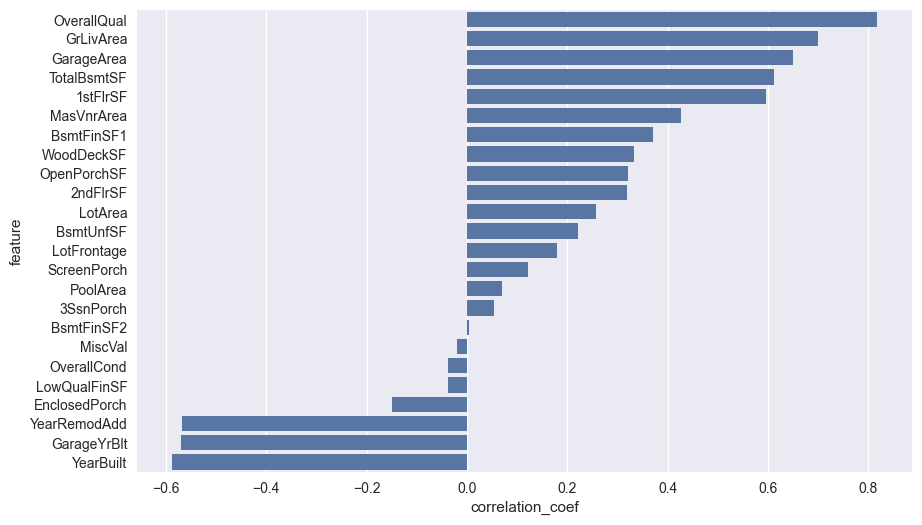

In [22]:
cor = correlation(target, train_clean, numeric, method = 'pearson')

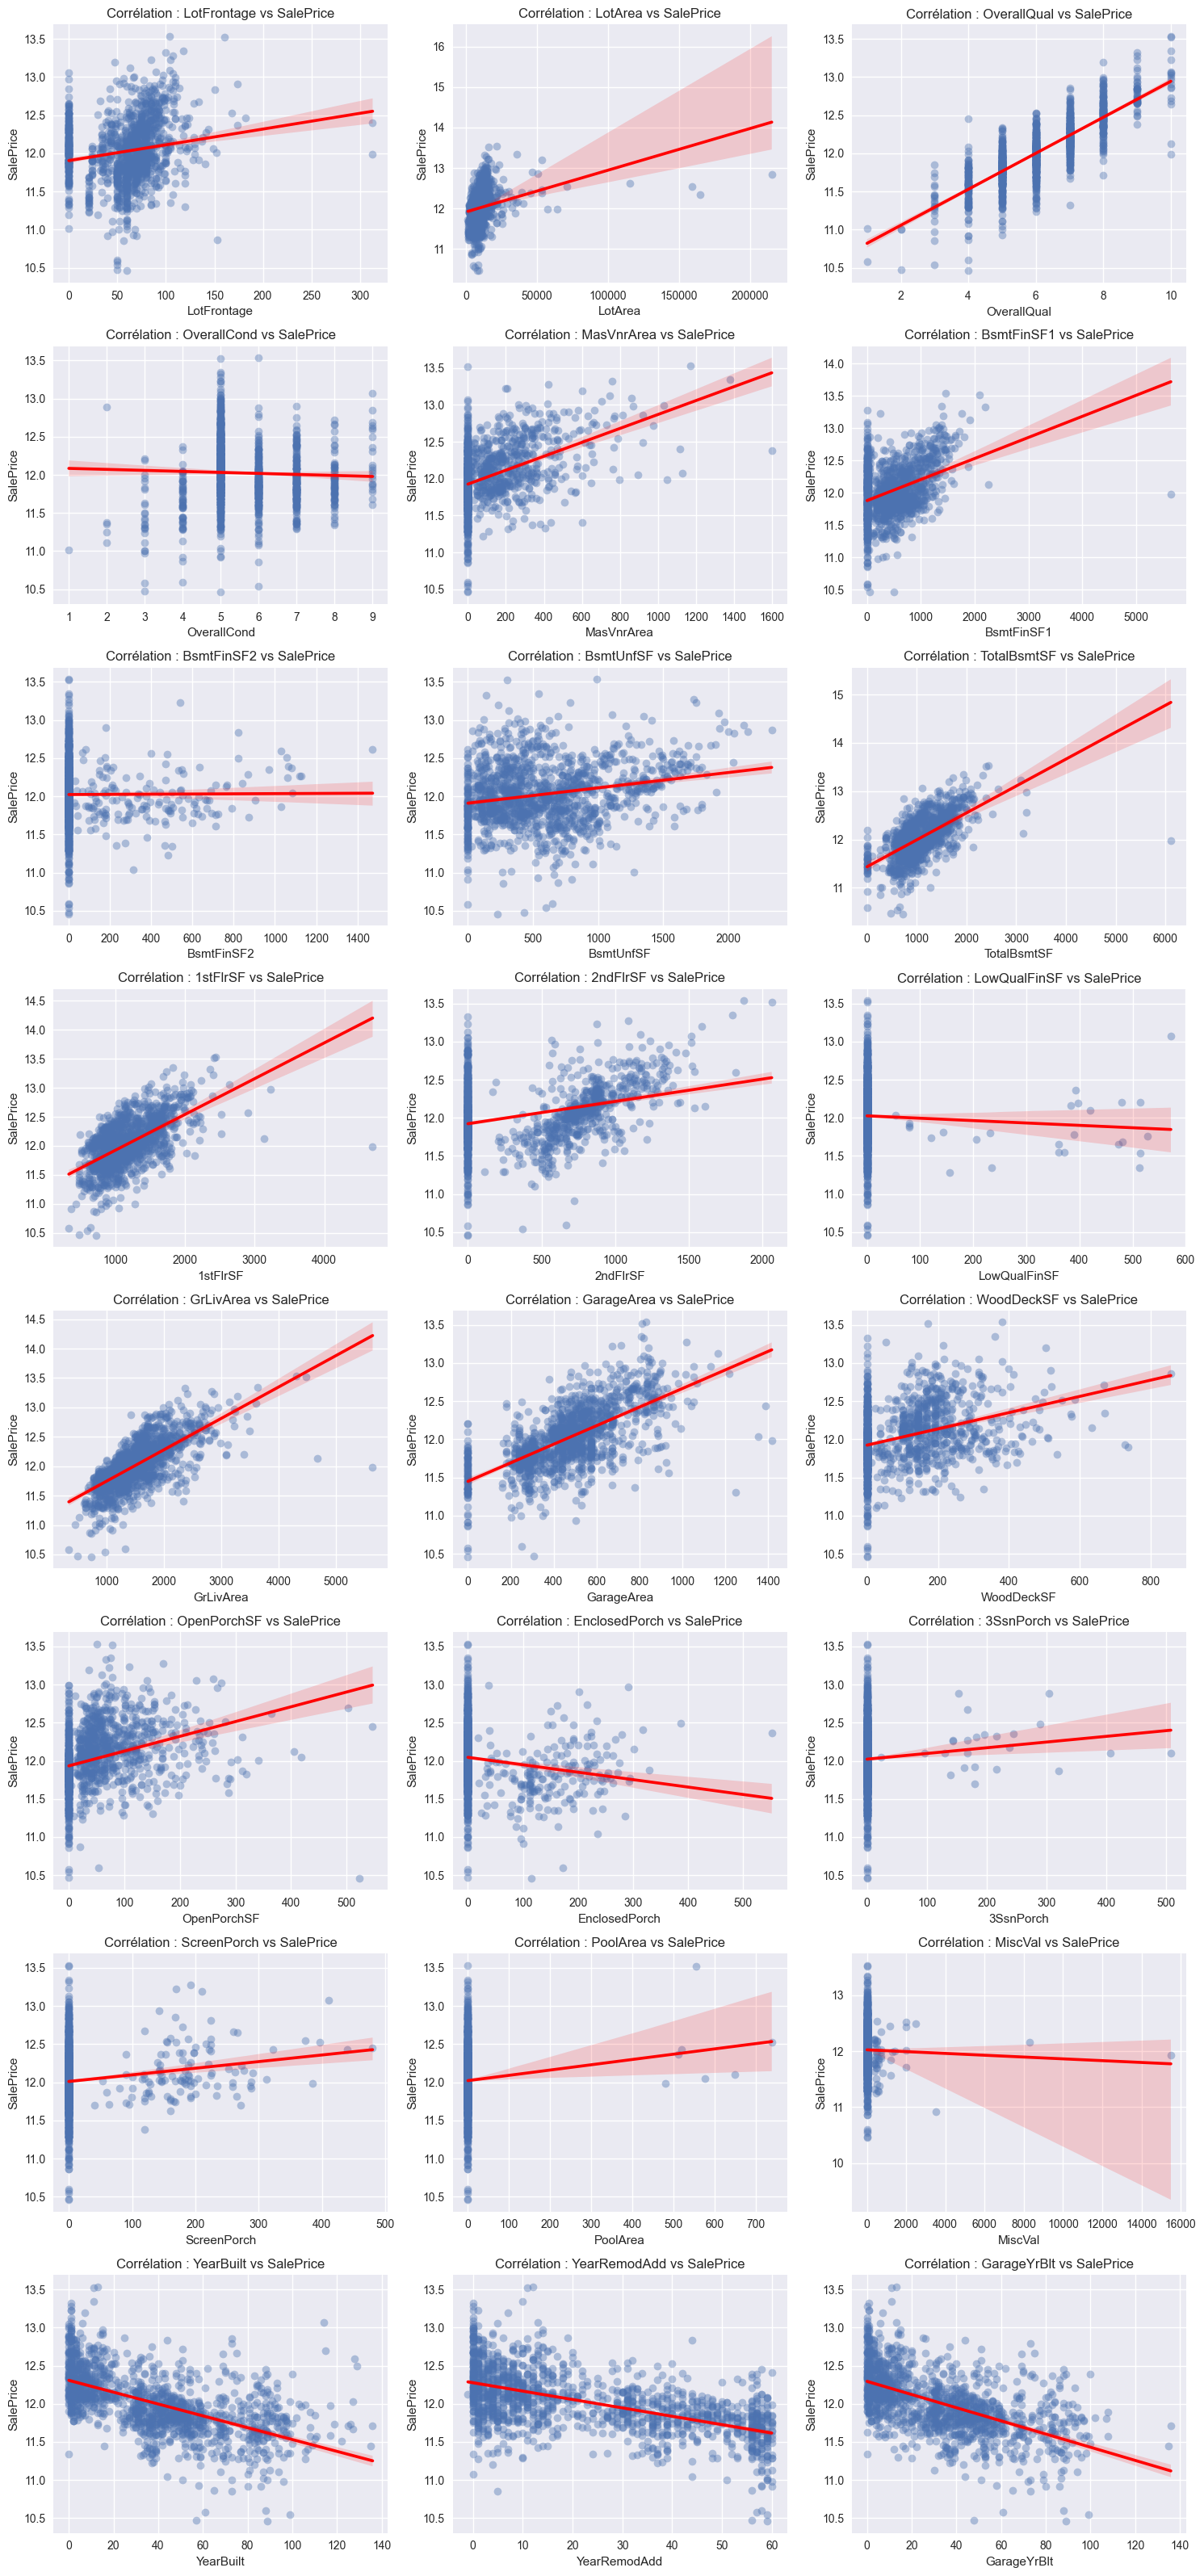

In [23]:
def scatter_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        x = X[f]
        sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
        axes[i].set_title(f'Corrélation : {f} vs {y.name}')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

scatter_plots_grid(target, train_clean, numeric)

Les 24 graphiques présentés ci-dessus illustrent les relations entre diverses variables numériques et le prix de vente (`SalePrice`, transformé en logarithme). Ces visualisations permettent d’identifier rapidement les variables ayant un impact significatif sur le prix et celles qui peuvent être exclues de notre modélisation.

### Variables avec une forte corrélation

| Variable    |
| ----------- |
| OverallQual |
| GrLivArea   |
| TotalBsmtSF |
| 1stFlrSF    |
| GarageArea  |

Les analyses quantitatives confirment que l’évaluation de la qualité générale (`OverallQual`), la surface habitable au-dessus du sol (`GrLivArea`), la surface totale du sous-sol (`TotalBsmtSF`), la surface du rez-de-chaussée (`1stFlrSF`) et la superficie du garage (`GarageArea`) entretiennent une corrélation élevée et linéaire avec le prix de vente. Ces caractéristiques traduisent des dimensions physiques tangibles et des qualités perçues qui constituent des indicateurs robustes de la valeur immobilière. Par conséquent, elles méritent d’être prioritairement intégrées au modèle.

### Variables avec une corrélation modérée

| Variable    |
| ----------- |
| LotArea     |
| MasVnrArea  |
| WoodDeckSF  |
| OpenPorchSF |
| ScreenPorch |
| PoolArea    |

Dans un second groupe, les variables de dimension plus accessoire (surface du lot, surface de parement en briques, terrasse, porche ou piscine) présentent un lien modéré avec le log-prix. Bien qu’elles n’agissent pas comme des moteurs principaux, ces attributs complémentaires peuvent affiner l’estimation dans des segments de marché spécifiques, notamment lorsque leur présence se conjugue avec de fortes surfaces principales.

### Variables avec peu ou pas de lien apparent

| Variable     |
| ------------ |
| LotFrontage  |
| OverallCond  |
| BsmtUnfSF    |
| BsmtFinSF2   |
| 2ndFlrSF     |
| GarageYrBlt  |
| YearBuilt    |
| YearRemodAdd |

Un troisième ensemble de variables révèle peu ou pas de liaison visible : certaines valeurs restent dispersées ou horizontales dans les nuages de points (largeur de façade, état général, surfaces partielles du sous-sol ou second étage, ancienneté brute de la construction ou de la rénovation). Leur reprise directe sous forme linéaire n’apporte pas de gain explicatif manifeste et pourrait être remplacée par des transformations ou des regroupements plus adaptés.

### Variables sans intérêt ou contre-productives

| Variable      |
| ------------- |
| LowQualFinSF  |
| EnclosedPorch |
| 3SsnPorch     |
| MiscVal       |

Enfin, certaines variables sont presque inutiles, bien que présentes : elles comptent un grand nombre de zéros et n’apportent aucun signal systématique (surfaces de faible qualité, petits patios ou valeurs accessoires mineures). Il apparaît judicieux de les exclure de l’ensemble initial de features ou, le cas échéant, de les traiter via des indicateurs binaires si l’on souhaite capter leur rareté plutôt que leur valeur absolue.


### 1.5.2 Analyse des variables catégorielles

L’analyse des variables qualitatives repose sur l’ANOVA à un facteur, une méthode qui permet de comparer les moyennes de la variable cible (logarithme de SalePrice) entre plusieurs groupes définis par les modalités d’une catégorie. En évaluant la variance intra-groupe et inter-groupe, l’ANOVA fournit un p-value pour chaque variable, traduite ici sous forme de “disparity” via la transformation logarithmique inverse du p-value. Plus cette mesure est élevée, plus les moyennes de prix diffèrent significativement selon les modalités, ce qui suggère un pouvoir discriminant élevé pour la variable considérée.

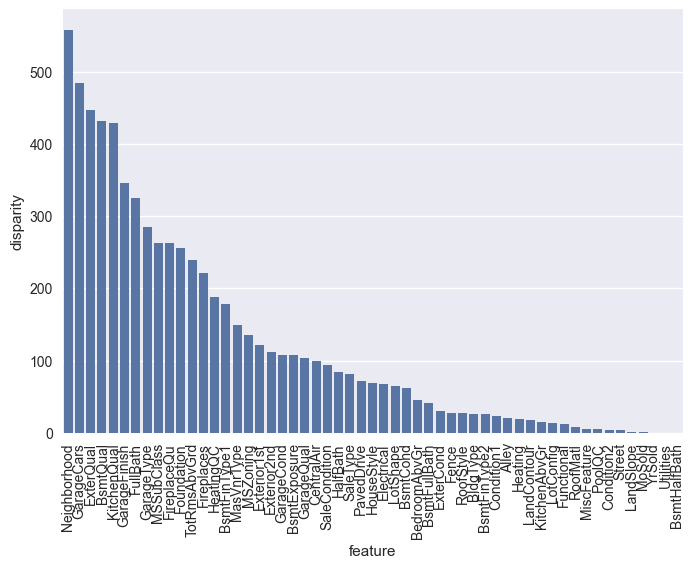

In [24]:
def anova(y, X, features):

    anova = pd.DataFrame()
    anova['feature'] = features
    pvals = []

    for f in features:

        samples = []

        for cls in X[f].unique():

            s = y[X[f] == cls].values
            samples.append(s)

        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)

    anova['pval'] = pvals
    anova = anova.sort_values('pval')

    anova['disparity'] = np.log(1. / anova['pval'].values)

    sns.barplot(data = anova, x = 'feature', y = 'disparity')
    x = plt.xticks(rotation=90)

    return anova

anova = anova(target, train_clean, categorical)

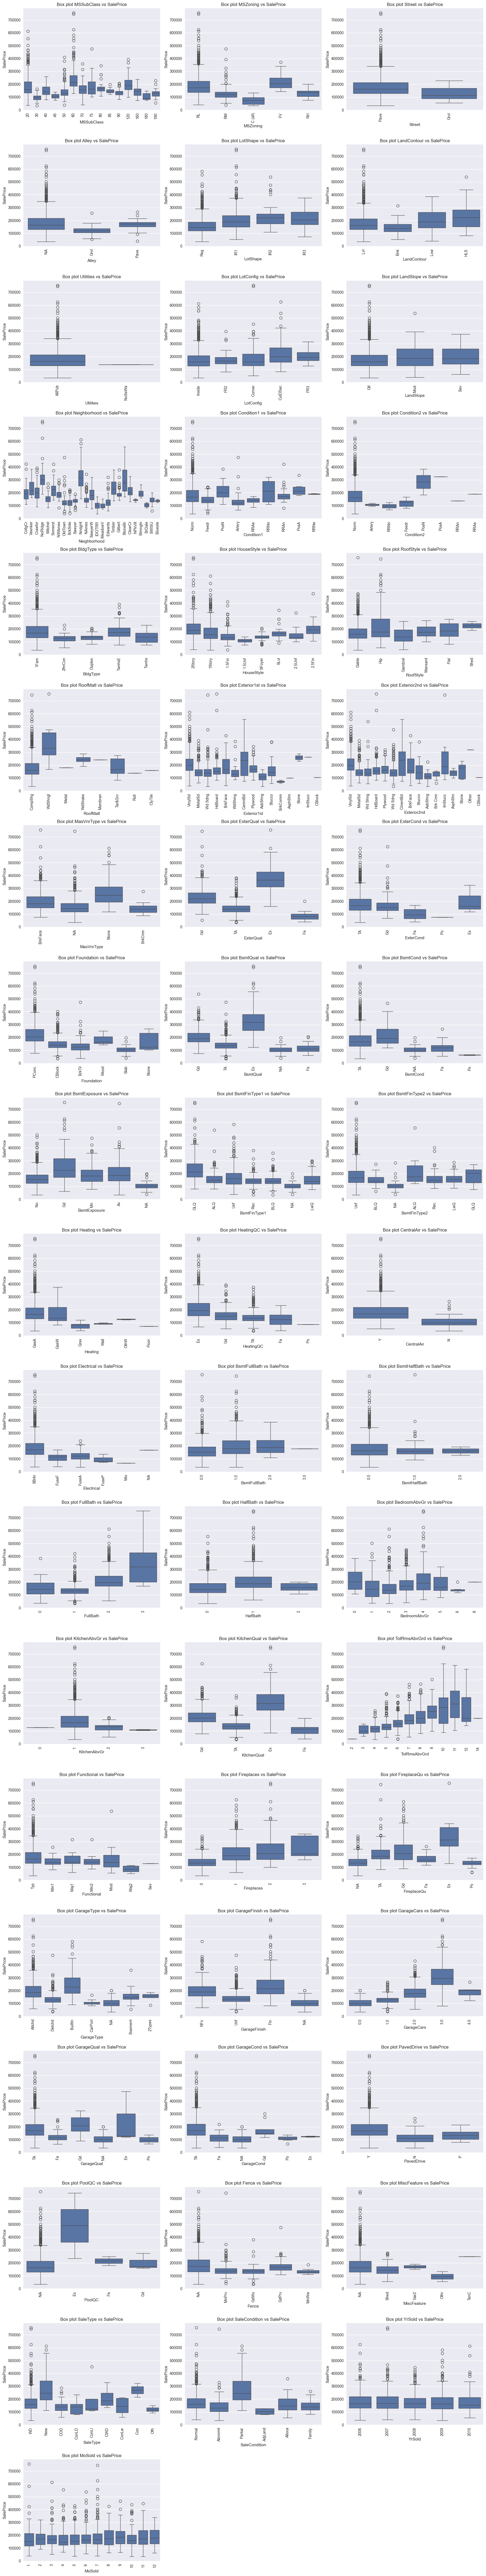

In [25]:
def box_plots_grid(y, X, features, cols=3):
    n = len(features)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for i, f in enumerate(features):
        sns.boxplot(x=X[f], y=y, ax=axes[i])
        axes[i].set_title(f'Box plot {f} vs {y.name}')
        axes[i].tick_params(axis='x', rotation=90)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

box_plots_grid(train_clean['SalePrice'], train_clean, categorical)

Le diagramme de l’ANOVA révèle que certaines variables catégorielles, notamment `Neighborhood`, `ExterQual` et `KitchenQual`, présentent une forte disparité de moyenne de prix entre leurs modalités, traduisant un impact significatif sur la valeur des biens. À l’inverse, des variables telles que `Street` ou `BsmtHalfBath` affichent une disparité faible, ce qui suggère qu’elles ne contribuent pas de manière déterminante à la variation du prix. Les boîtes à moustaches confirmatoires mettent en lumière la distribution de `SalePrice` au sein de chaque catégorie : les écarts inter-catégories pour les variables à haute disparité justifient leur inclusion prioritaire dans le modèle, tandis que les variables à faible séparation pourraient être exclues ou regroupées pour réduire la complexité et limiter le sur-apprentissage.

# Phase 2 : Phase de design

La phase de design consiste à traduire nos conclusions d’EDA en une architecture de modélisation cohérente et progressive. Nous débuterons par la spécification d’un modèle de référence simple, dont l’objectif est de servir de point d’ancrage pour évaluer les gains apportés par des méthodes plus sophistiquées. Ce modèle initial reposera sur une régression linéaire ordinaire appliquée aux variables retenues, mise en œuvre via un pipeline unifiant prétraitement et estimation. Nous définirons un protocole d’évaluation fondé sur la validation croisée, en utilisant l’erreur quadratique moyenne (RMSE) sur la cible transformée logarithmiquement comme métrique principale. Dans un second temps, nous introduirons des régularisations (Ridge, Lasso) pour contrôler le sur-apprentissage, puis nous explorerons des algorithmes non linéaires (arbres, forêts aléatoires) afin d’augmenter la capacité prédictive. À chaque étape, nous comparerons rigoureusement les performances et analyserons l’impact de chaque composant sur la robustesse et l’interprétabilité du modèle.


## 2.1 Ingénierie des données de base
Dans cette étape, nous enrichissons le jeu de données propre en convertissant les variables catégorielles en attributs numériques directement liés à la cible. Plutôt que de recourir à un encodage one‐hot classique—qui peut générer un très grand nombre de colonnes et diluer l’information—nous calculons pour chaque modalité la moyenne du logarithme du prix de vente observée dans l’ensemble d’apprentissage. Cette moyenne devient alors la valeur de la nouvelle variable. Ce procédé, parfois appelé “target encoding”, crée une corrélation naturelle et souvent plus stable avec la variable cible, tout en limitant la dimensionnalité. Il convient toutefois de rester vigilant aux risques de fuite d’information et de sur-apprentissage : ce type d’encodage nécessite idéalement un lissage ou une validation croisée interne pour prévenir la surestimation du pouvoir prédictif des catégories rares.

In [26]:
def encode_with_mean(data, target, features):

    data_preprocess = data.copy()

    for f in features:

        # create a temporary dataframe for our workload
        frame = pd.DataFrame()
        frame[f] = data[f].copy()
        frame[target.name] = target.copy()

        # create the mapping table
        mapping = pd.DataFrame()
        mapping['val'] = data[f].unique()
        mapping.index = mapping.val

        # compute the mean of our target variable for each category
        mapping['mean'] = frame[[f, target.name]].groupby(f).mean()[target.name]

        # if a category has NA, we shall simply put the mean value
        mapping['mean'] = mapping['mean'].fillna(target.mean())

        # we replace the feature with the means in the mapping table
        data_preprocess[f] = pd.merge(data_preprocess, mapping, left_on = f, right_index = True)['mean'].copy()

    return data_preprocess

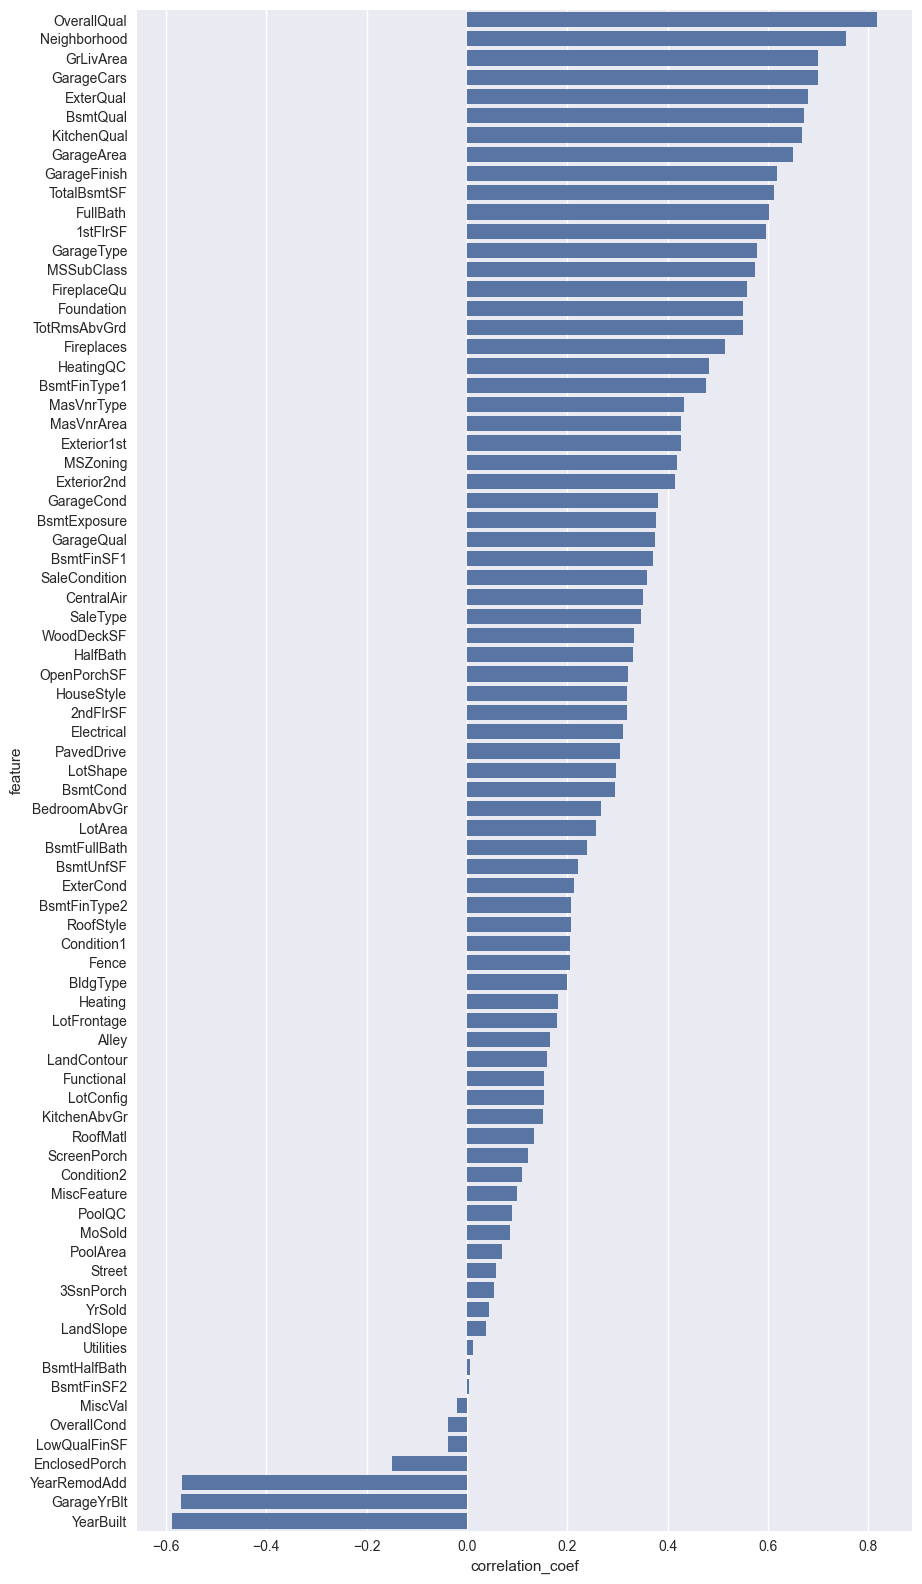

In [27]:
data_preprocess = encode_with_mean(data_clean, target, categorical)

# Split of the clean dataset into train & validation
train_preprocess = data_preprocess[data_preprocess.index.isin(train_raw.index)]
validation_preprocess = data_preprocess[data_preprocess.index.isin(validation_raw.index)]

cor = correlation(target, train_preprocess, numeric + categorical)

Le calcul de la corrélation combinée sur l’ensemble prétraité révèle que de nombreuses variables, tant numériques que nouvellement encodées, présentent une association significative avec le log-prix. L’affichage de la matrice de corrélation limitée aux coefficients supérieurs à 0,5 met en évidence un réseau de dépendances croisées très dense. Cette forte multicolinéarité impose de restreindre le jeu de variables ou d’introduire des pénalités (par exemple Ridge ou Lasso) pour stabiliser les estimations des coefficients. Alternativement, une sélection de variables basée sur des critères d’importance ou une réduction de dimension par méthodes factorisées (PCA) pourrait alléger le modèle sans compromettre sensiblement son pouvoir explicatif.

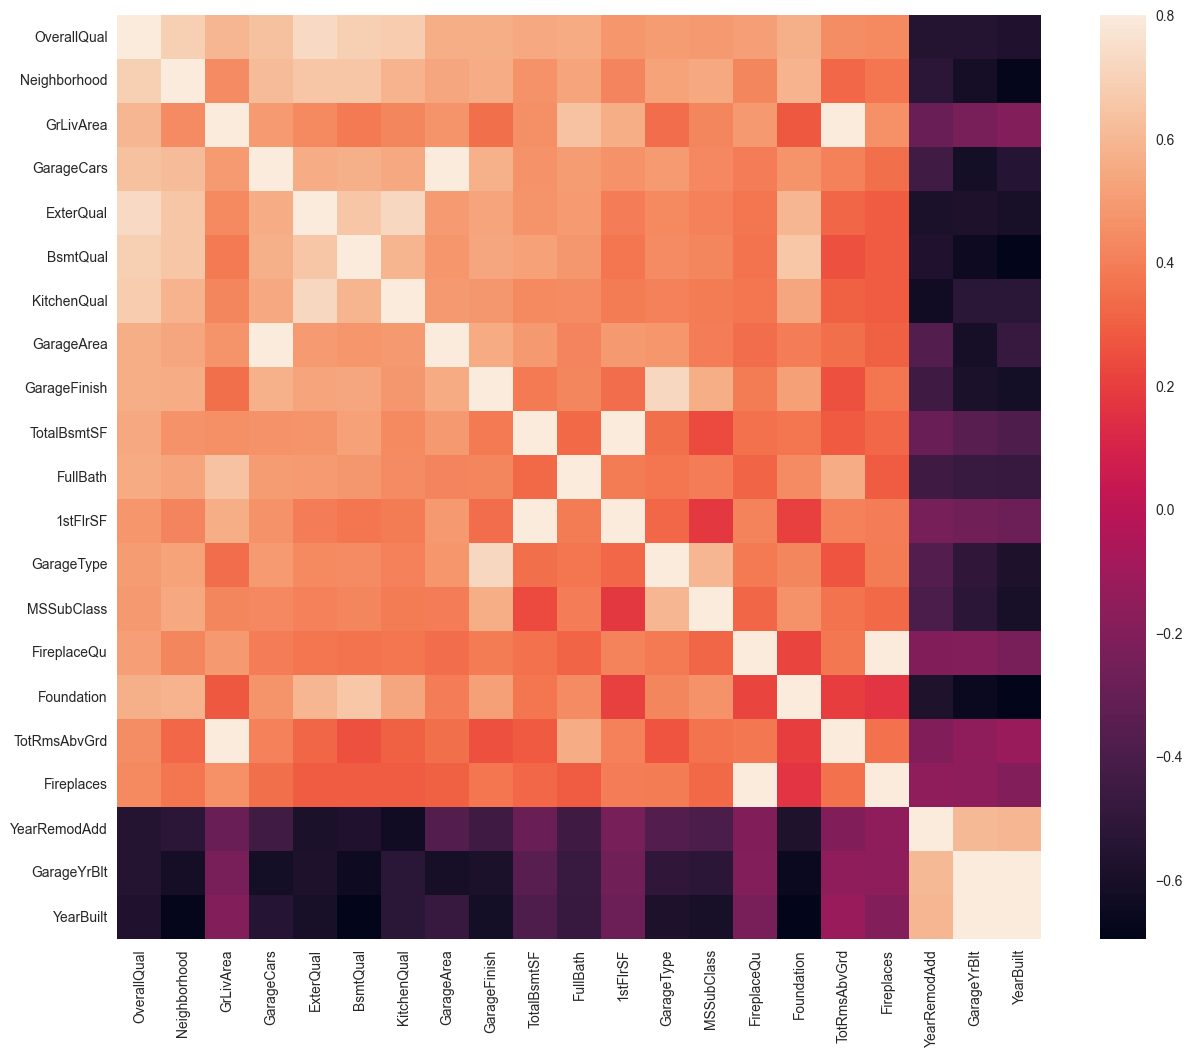

In [28]:
cols = cor[abs(cor['correlation_coef']) > 0.5]['feature'].tolist()
correlation_matrix = train_preprocess[cols].corr()
f, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(correlation_matrix, vmax=.8, square=True)
plt.show()

Il y a beaucoup de corrélation interne. Nous devrons donc sélectionner soigneusement les variables afin d'éviter la multicolinéarité.

## 2.2 Modèle de base - régression linéaire
La construction d’un modèle de référence repose sur un ensemble minimal de variables sélectionnées pour leur pouvoir explicatif et leur pertinence métier. Nous retenons la qualité générale (OverallQual), l’emplacement géographique (Neighborhood), la surface habitable (GrLivArea), la surface du sous-sol (TotalBsmtSF) et l’ancienneté de la construction (YearBuilt). Ce choix s’appuie sur l’EDA précédent et sur la connaissance spécifique de la région d’Ames, où la présence d’un sous-sol robuste constitue un élément structurant en raison du risque de tornades. L’objectif de cette régression linéaire simple est d’établir un point de comparaison clair avant d’introduire des régularisations ou des modèles non linéaires.

In [29]:
base = ['OverallQual', 'Neighborhood', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt']

X = train_preprocess[base]
X_val = validation_preprocess[base]

y = target.copy()

model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     1367.
Date:                Fri, 20 Jun 2025   Prob (F-statistic):               0.00
Time:                        17:26:21   Log-Likelihood:                 539.40
No. Observations:                1460   AIC:                            -1067.
Df Residuals:                    1454   BIC:                            -1035.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.8392      0.271     25.244   

Le résumé du modèle met en évidence une capacité d’ajustement notable, avec un coefficient de détermination ajusté indiquant que plus de trois quarts de la variance du log-prix sont expliqués par ces cinq variables. La qualité générale (OverallQual) apparaît avec un coefficient positif fortement significatif (p < 0,001), suggérant qu’une unité supplémentaire sur cette échelle se traduit par une hausse substantielle du prix estimé. La surface habitable (GrLivArea) et la surface du sous-sol (TotalBsmtSF) présentent également des effets linéaires positifs et hautement significatifs, quoique d’amplitude moindre en raison de leur échelle de mesure. L’effet de l’année de construction (YearBuilt) se révèle moins prononcé, avec un p-value autour de 0,05, ce qui peut indiquer un rôle secondaire ou une colinéarité partielle avec d’autres variables. Enfin, la variable encodée Neighborhood montre des coefficients variables selon les quartiers, certains secteurs entraînant un ajustement positif significatif, d’autres étant non distincts du niveau de référence.

Le diagnostic des résidus (non présenté ici) devra confirmer l’homoscédasticité et l’absence de biais de spécification. Cette régression de base sert désormais de référence pour évaluer les gains potentiels introduits par des pénalités ou des modélisations plus complexes.

In [30]:
model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     1367.
Date:                Fri, 20 Jun 2025   Prob (F-statistic):               0.00
Time:                        17:26:21   Log-Likelihood:                 539.40
No. Observations:                1460   AIC:                            -1067.
Df Residuals:                    1454   BIC:                            -1035.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.8392      0.271     25.244   

### 2.2.1 Hypothèses de régression linéaire
La validité d’une régression linéaire repose sur plusieurs hypothèses fondamentales relatives au comportement des résidus et à la forme des relations. Il convient de vérifier la linéarité du lien entre les variables explicatives et la variable cible, la distribution normale des résidus centrés sur zéro, l’homoscédasticité, l’absence de structure (autocorrélation) et l’inexistence de points aberrants influents.

Les graphiques diagnostics (résidus vs ajustés, Q-Q plot, Scale-Location, Résidus vs Leverage) fournissent un diagnostic visuel complet de ces conditions.

Le code ci-dessous génère ces quatre tracés, enrichis d’annotations pour identifier les trois observations les plus extrêmes selon chaque critère, et superpose les courbes de Cook permettant de détecter les observations à forte influence.

In [31]:
from statsmodels.graphics.gofplots import ProbPlot
plt.rc('font', size=14)
plt.rc('figure', titlesize=18)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=18)

def graph(formula, x_range, label=None):
    """
    Helper function for plotting cook's distance lines
    """
    x = x_range
    y = formula(x)
    plt.plot(x, y, label=label, lw=1, ls='--', color='red')


def diagnostic_plots(X, y, model_fit=None):
    """
    Function to reproduce the 4 base plots of an OLS model in R.

    ---
    Inputs:

    X: A numpy array or pandas dataframe of the features to use in building the linear regression model
    y: A numpy array or pandas series/dataframe of the target variable of the linear regression model

    model_fit [optional]: a statsmodel.api.OLS model after regressing y on X. If not provided, will be
                        generated from X, y
    """

    if not model_fit:
        model_fit = sm.OLS(y, sm.add_constant(X)).fit()

    # create dataframe from X, y for easier plot handling
    dataframe = pd.concat([X, y], axis=1)

    # model values
    model_fitted_y = model_fit.fittedvalues
    # model residuals
    model_residuals = model_fit.resid
    # normalized residuals
    model_norm_residuals = model_fit.get_influence().resid_studentized_internal
    # absolute squared normalized residuals
    model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
    # absolute residuals
    model_abs_resid = np.abs(model_residuals)
    # leverage, from statsmodels internals
    model_leverage = model_fit.get_influence().hat_matrix_diag
    # cook's distance, from statsmodels internals
    model_cooks = model_fit.get_influence().cooks_distance[0]

    plot_lm_1 = plt.figure()
    plot_lm_1.axes[0] = sns.residplot(x = model_fitted_y, y = dataframe.columns[-1], data = dataframe,
                                      lowess=True,
                                      scatter_kws={'alpha': 0.5},
                                      line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

    plot_lm_1.axes[0].set_title('Residuals vs Fitted')
    plot_lm_1.axes[0].set_xlabel('Fitted values')
    plot_lm_1.axes[0].set_ylabel('Residuals');

    # annotations
    abs_resid = model_abs_resid.sort_values(ascending=False)
    abs_resid_top_3 = abs_resid[:3]
    for i in abs_resid_top_3.index:
        plot_lm_1.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_residuals[i]));

    QQ = ProbPlot(model_norm_residuals)
    plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
    plot_lm_2.axes[0].set_title('Normal Q-Q')
    plot_lm_2.axes[0].set_xlabel('Theoretical Quantiles')
    plot_lm_2.axes[0].set_ylabel('Standardized Residuals');

    # annotations
    abs_norm_resid = np.flip(np.argsort(np.abs(model_norm_residuals)), 0)
    abs_norm_resid_top_3 = abs_norm_resid[:3]
    for r, i in enumerate(abs_norm_resid_top_3):
        plot_lm_2.axes[0].annotate(i,
                                   xy=(np.flip(QQ.theoretical_quantiles, 0)[r],
                                       model_norm_residuals[i]));

    plot_lm_3 = plt.figure()
    plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5);
    sns.regplot(x = model_fitted_y, y = model_norm_residuals_abs_sqrt,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_3.axes[0].set_title('Scale-Location')
    plot_lm_3.axes[0].set_xlabel('Fitted values')
    plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');

    # annotations
    abs_sq_norm_resid = np.flip(np.argsort(model_norm_residuals_abs_sqrt), 0)
    abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
    for i in abs_norm_resid_top_3:
        plot_lm_3.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_norm_residuals_abs_sqrt[i]));

    plot_lm_4 = plt.figure();
    plt.scatter(model_leverage, model_norm_residuals, alpha=0.5);
    sns.regplot(x = model_leverage, y = model_norm_residuals,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_4.axes[0].set_xlim(0, max(model_leverage)+0.01)
    plot_lm_4.axes[0].set_ylim(-3, 5)
    plot_lm_4.axes[0].set_title('Residuals vs Leverage')
    plot_lm_4.axes[0].set_xlabel('Leverage')
    plot_lm_4.axes[0].set_ylabel('Standardized Residuals');

    # annotations
    leverage_top_3 = np.flip(np.argsort(model_cooks), 0)[:3]
    for i in leverage_top_3:
        plot_lm_4.axes[0].annotate(i,
                                   xy=(model_leverage[i],
                                       model_norm_residuals[i]));

    p = len(model_fit.params) # number of model parameters
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50),
          'Cook\'s distance') # 0.5 line
    graph(lambda x: np.sqrt((1 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50)) # 1 line
    plot_lm_4.legend(loc='upper right');

<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\s'
/var/folders/8p/yp11388s4wggmhjlnzpg0clr0000gn/T/ipykernel_17453/2729062031.py:92: SyntaxWarning: invalid escape sequence '\s'
  plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');


/Users/cutiips/Code/OverfittingRepo/.venv/lib/python3.13/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


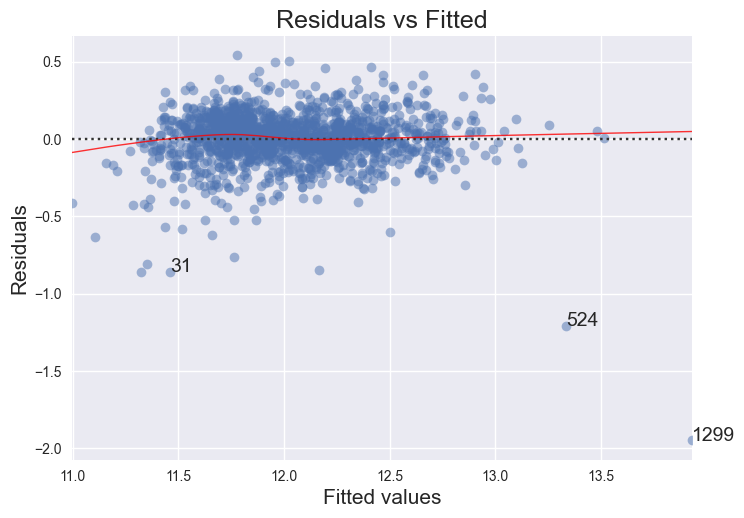

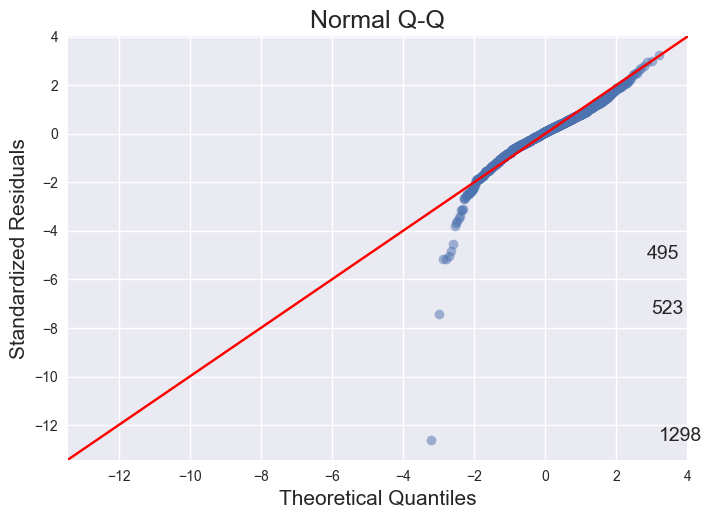

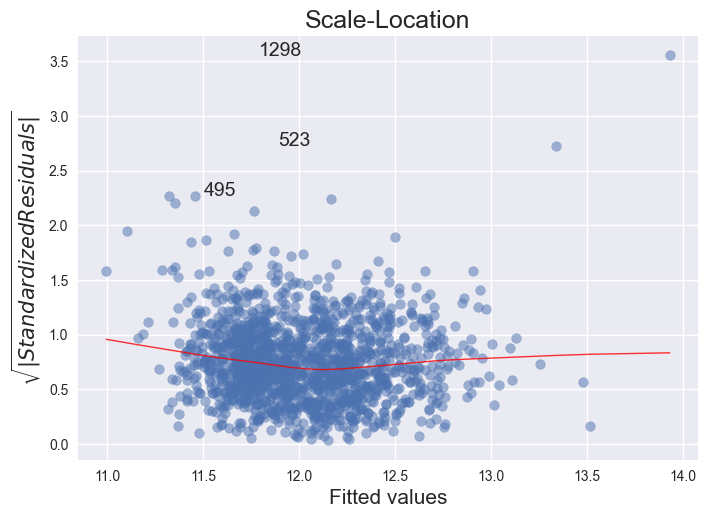

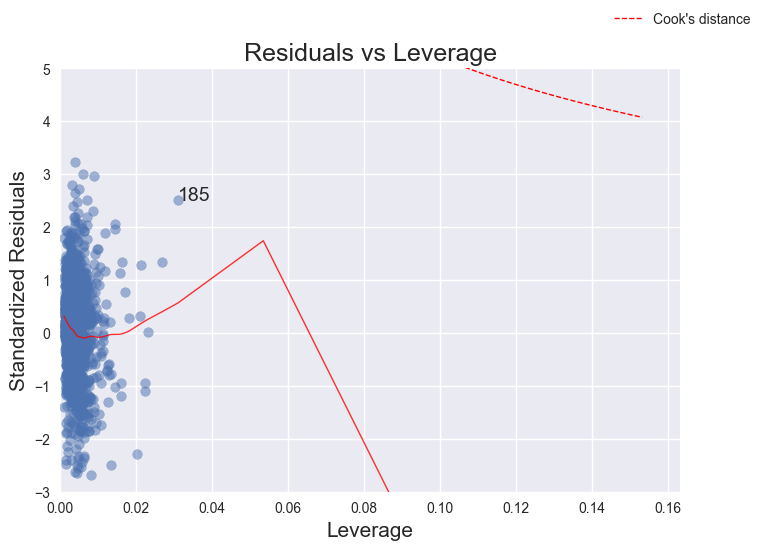

In [32]:
diagnostic_plots(sm.add_constant(X), y)

L’examen des graphiques diagnostics révèle plusieurs enseignements. Le tracé “Residuals vs Fitted” doit montrer une répartition aléatoire et centrée ; toute structure en forme de U ou de tendance linéaire indiquerait une spécification incomplète. Le Q-Q plot permet de juger de la normalité des résidus ; un alignement proche de la diagonale 45° atteste de cette hypothèse. Le graphique “Scale-Location” évalue l’homoscédasticité ; une ligne horizontale suggère une variance constante des résidus. Enfin, le diagramme “Residuals vs Leverage” met en évidence les observations à forte influence via les courbes de Cook. Si des points se situent au-dessus des seuils (0,5 ou 1), ils méritent une enquête plus approfondie ou une éventuelle exclusion. Ces diagnostics confirment si les hypothèses de la régression linéaire sont globalement respectées ou si des ajustements (transformation de variables, suppression de points aberrants) sont nécessaires avant de poursuivre.

### 2.2.2 Analyse résiduelle
Pour identifier les observations dont les résidus extrêmes pourraient fausser l’ajustement, nous extrayons les lignes d’index 523 et 1298. Cette inspection permet de vérifier si ces points correspondent à des ventes atypiques — par exemple des surfaces exceptionnellement grandes ou des prix partiels — et de décider rationnellement de leur maintien ou de leur exclusion.

In [33]:
print(X[base].iloc[[523, 1298]])

      OverallQual  Neighborhood  GrLivArea  TotalBsmtSF  YearBuilt
Id                                                                
524            10     11.712321       4676       3138.0          0
1299           10     11.712321       5642       6110.0          0


In [34]:
def remove_outliers(data, target, feature):

    data_preprocess = data.copy()
    data_preprocess[target.name] = target.copy()

    #Compute interquartile range
    q1 = data_preprocess[feature].quantile(0.25)
    q3 = data_preprocess[feature].quantile(0.75)

    iqr = q3-q1

    fence_low  = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr

    data_preprocess = data_preprocess.loc[(data_preprocess[feature] > fence_low) & (data_preprocess[feature] < fence_high)]

    return data_preprocess[data.columns], data_preprocess[target.name]

Après suppression des observations les plus influentes sur la variable GrLivArea via la méthode des « fences » (IQR), le réajustement du modèle linéaire présente généralement un coefficient de détermination ajusté plus élevé et des résidus mieux centrés et répartis, sans points extrêmes susceptibles de violer les hypothèses d’homoscédasticité ou de linéarité. Les graphiques diagnostics mettent en évidence une distribution plus conforme des résidus autour de zéro et une diminution des observations à forte distance de Cook, attestant de la robustesse accrue du modèle après cette purge ciblée.

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     1522.
Date:                Fri, 20 Jun 2025   Prob (F-statistic):               0.00
Time:                        17:26:21   Log-Likelihood:                 659.93
No. Observations:                1429   AIC:                            -1308.
Df Residuals:                    1423   BIC:                            -1276.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.7556      0.257     30.195   

/Users/cutiips/Code/OverfittingRepo/.venv/lib/python3.13/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


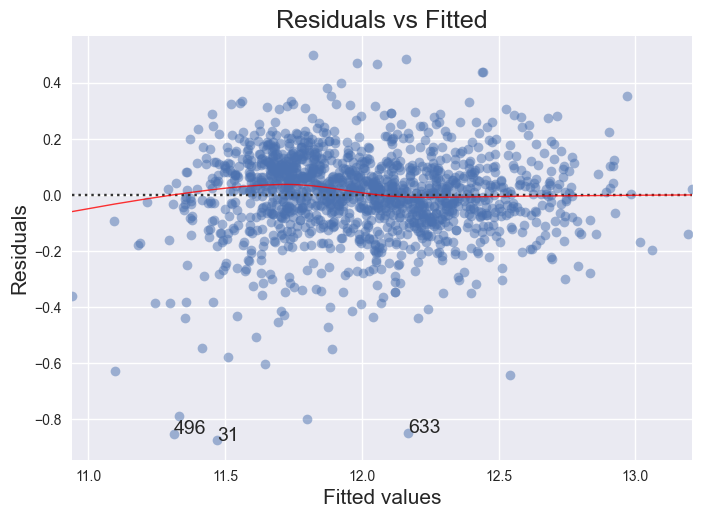

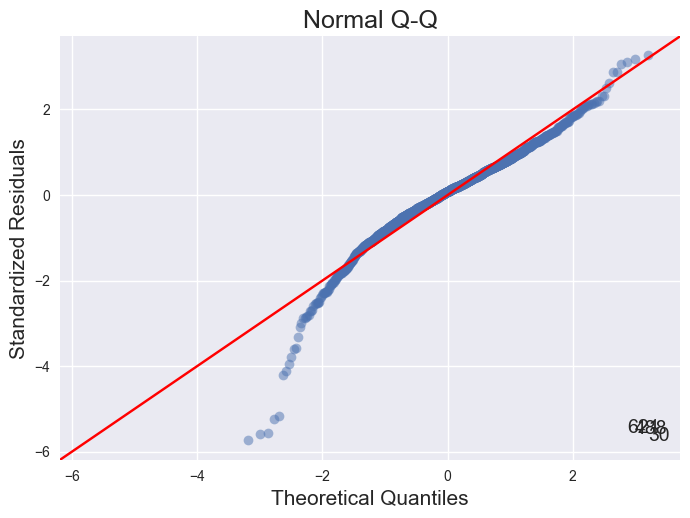

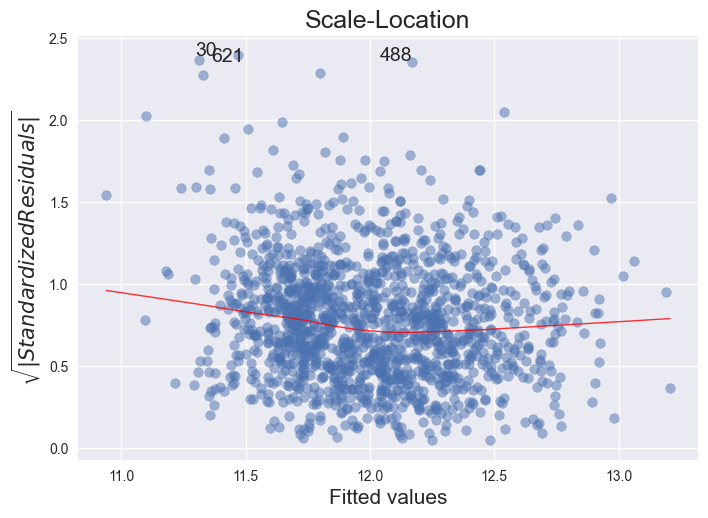

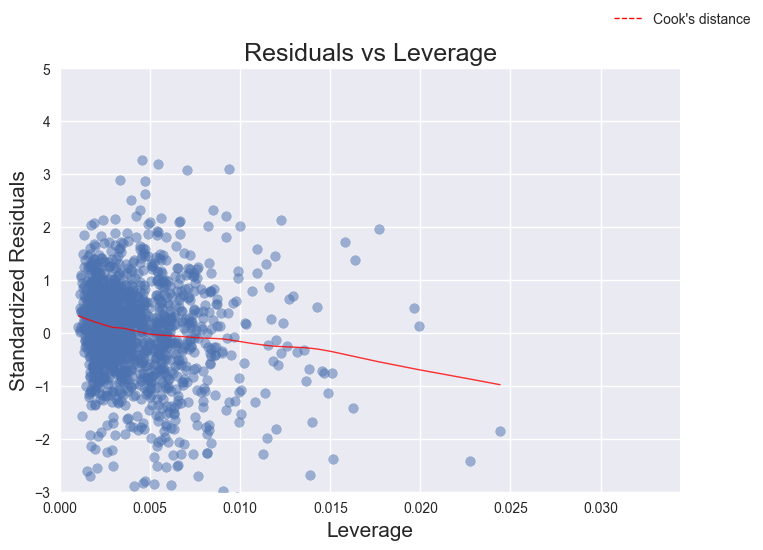

In [35]:
# exécution de la fonction pour supprimer les valeurs aberrantes

X, y = remove_outliers(X, y, feature = 'GrLivArea')

model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

diagnostic_plots(sm.add_constant(X), y)

### 2.2.3 résumé de nos actions sur le modèle de base
Nous avons d’abord sélectionné un jeu réduit de variables, fondé sur l’exploration et la connaissance métier : qualité générale, quartier, surface habitable, surface du sous-sol et année de construction.

Après encodage des variables catégorielles par moyenne cible et imputation homogène des données manquantes, nous avons ajusté une régression linéaire simple à l’aide de StatsModels.

L’évaluation initiale par le R² ajusté a montré qu’une large part de la variance du log-prix était expliquée.

Nous avons ensuite validé les hypothèses classiques (linéarité, normalité et homoscédasticité des résidus, absence de structure et points influents) à l’aide de graphiques diagnostics.

Les outliers identifiés via la distance de Cook et l’IQR sur la surface habitable ont été retirés, conduisant à un ajustement plus robuste et à des résidus conformes aux hypothèses de la régression.

Cette base constitue désormais notre référence pour mesurer l’apport des modèles régularisés et non linéaires.

### 2.2.4 Évaluation du modèle de base
Nous évaluons à présent le comportement de notre régression linéaire simple en générant des prédictions in-sample, c’est-à-dire sur les mêmes données utilisées pour l’ajustement. Cette procédure, bien que propice à déceler un éventuel sur-apprentissage, nous permet d’obtenir un premier ordre de grandeur de la qualité de l’ajustement avant de passer à une validation externe ou croisée.

In [36]:
y_pred = res.predict(sm.add_constant(X))
print(y_pred.head())

Id
1    12.214534
2    12.081588
3    12.244451
4    12.046219
5    12.620316
dtype: float64


Après avoir appliqué res.predict() pour obtenir les valeurs prédites, nous représenterons graphiquement le nuage « réel vs prédit » pour visualiser la concordance générale, puis nous calculerons l’erreur quadratique moyenne (RMSE) afin de disposer d’une métrique synthétique de performance.

Enfin, il conviendra de répéter ces mêmes opérations sur un jeu de validation ou via une méthode de cross-validation pour confirmer la robustesse du modèle hors échantillon.

In [37]:
def plot_prediction(actual, predicted) :

    data = pd.concat([actual, predicted], keys = ['actual', 'predicted'], axis = 1)

    plt.title('Actual vs Predicted')
    sns.regplot(x = 'actual', y = 'predicted', data = data)
    plt.show()

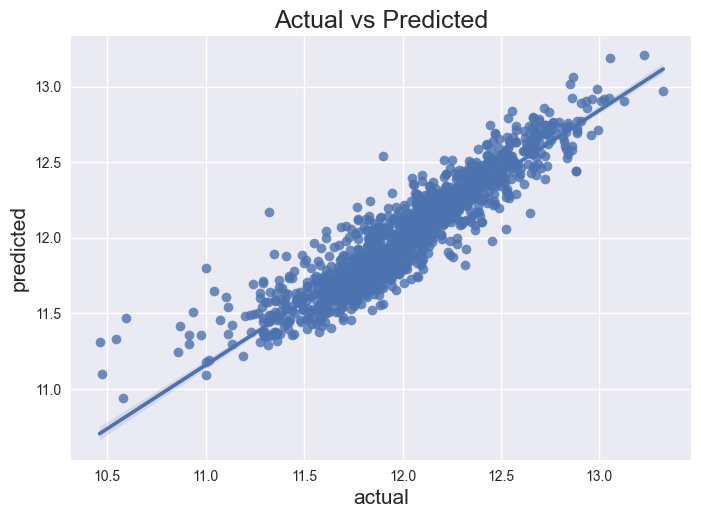

In [38]:
plot_prediction(y, y_pred)

Cela semble fonctionner correctement. Attention au surapprentissage ici, car nous avons prédit et ajusté sur le même ensemble de données. Pour des modèles plus complexes, cela pourrait poser un problème sérieux.

In [39]:
def rmse(actual, predicted) :
    return np.sqrt(mean_squared_error(actual, predicted))

In [40]:
print('Root Mean Square Error (RMSE) :', rmse(y, y_pred))

Root Mean Square Error (RMSE) : 0.15247508062910983


### 2.3 Soumission du modèle Baseline sur Kaggle

Après avoir ajusté et évalué notre modèle sur l’échantillon d’entraînement, nous générons les prédictions pour le jeu de validation à l’aide de `res.predict()`. Comme notre modèle est calibré sur le logarithme du prix de vente, nous appliquons la fonction inverse `np.expm1` pour retrouver les valeurs en euros avant d’écrire le fichier de soumission. Le fichier `baseline.csv` ainsi constitué, associant chaque `Id` à son estimation de `SalePrice`, est prêt à être envoyé sur la plateforme Kaggle pour obtenir notre score public.  

In [41]:
y_val = res.predict(sm.add_constant(X_val))

print(y_val.head())

Id
1461    11.663271
1462    11.946171
1463    12.025787
1464    12.101195
1465    12.341289
dtype: float64


Nous écrivons maintenant nos prédictions dans le fichier _baseline.csv_ et n'oublions pas d'utiliser la fonction inverse de **np.log1p**, à savoir **np.expm1**.

In [42]:
submission = pd.DataFrame()
submission['Id'] = y_val.index
submission['SalePrice'] = np.expm1(y_val.values)

submission.to_csv('Data/baseline.csv', index = False)

## Résumé de la Phase 2.1 et 2.2

### Bilan Phase 2.1 & 2.2 – baseline

| Modèle                         | RMSE validation (log) | Score Kaggle (RMSLE) |
|--------------------------------|-----------------------|----------------------|
| LinearRegression (baseline)    | **0.1525**            | **0.16913**          |
| Ridge (pipeline + Optuna)      | **0.1398**            | **0.13095**          |

> Le pipeline propre (-9 % de RMSE) se traduit par **-23 %** de RMSLE sur Kaggle.


Au cours de cette phase, nous avons construit un **modèle baseline** de régression linéaire sur un sous-ensemble de variables sélectionnées pour leur pertinence métier et leur corrélation avec le prix (`SalePrice`) : `OverallQual`, `Neighborhood`, `GrLivArea`, `TotalBsmtSF` et `YearBuilt`.

Pour améliorer la stabilité du modèle, nous avons :

* Nettoyé les données en supprimant des **valeurs aberrantes** sur la variable `GrLivArea`.  
* Transformé les variables catégorielles (`Neighborhood`) via un **encodage par moyenne cible**, plus adapté au contexte d'une régression linéaire que l'encodage one-hot classique.  
* Vérifié les hypothèses du modèle à travers une **analyse des résidus** (distribution normale, homoscédasticité, leverage).  

Le modèle obtenu présente des performances solides :

* **R² = 0.842**, ce qui signifie qu’il explique 84,2 % de la variance des prix.  
* **RMSE (log) ≈ 0.152**, indiquant une erreur relative moyenne raisonnable.  
* Les diagnostics montrent une **réduction des biais et une meilleure distribution des résidus**.  

Enfin, ce modèle a été utilisé pour générer une **soumission Kaggle**, servant ainsi de **référence** pour la suite du projet.

---

### Poursuite de la Phase 2.1 – Mise en place d’un pipeline `sklearn`

Avant de passer à la phase de modélisation avancée, nous allons poursuivre la phase 2.1 en construisant un **pipeline `scikit-learn` complet**. Celui-ci permettra :

* D’automatiser le traitement des données : encodage, imputation, standardisation.  
* De garantir la reproductibilité et la cohérence entre les données d’entraînement et de test.  
* De simplifier l’évaluation de modèles plus complexes par la suite.  

---

### Phase 2.2 – Model Engineering : tests de modèles avancés

Une fois le pipeline mis en place, nous entamerons la phase 2.2, dédiée à l’**exploration de modèles plus puissants** :

* Régressions régularisées : **Ridge**, **Lasso**, **ElasticNet**.  
* Modèles d’ensemble : **Random Forest**, **Gradient Boosting** (XGBoost, LightGBM).  
* Optimisation automatique des hyperparamètres à l’aide de la librairie Optuna, pour gagner en efficacité et en performance.  
* Évaluation rigoureuse par **validation croisée**.  

L’objectif sera d’obtenir un modèle **plus performant que notre baseline**, mieux généralisable et plus robuste.  


# 2.4 Mise en place d’un pipeline de prétraitement commun

Avant de comparer différents modèles de régression, nous construisons un pipeline scikit-learn qui regroupe toutes les étapes de préparation des données. Cela garantit que :

Chaque modèle reçoit les mêmes données correctement transformées.
Le code reste modulaire, clair et facilement extensible.
Les performances des modèles sont comparables dans des conditions identiques.

Notre pipeline inclut :

L’imputation des données manquantes (médiane pour les numériques, constante 'NA' pour les catégorielles),

L’encodage des variables catégorielles nominales via OneHotEncoder,

La standardisation des variables numériques via StandardScaler.

Nous utilisons ensuite ce pipeline pour entraîner nos modèles (Ridge, Lasso, Random Forest et XGBoost) avec ou sans recherche d’hyperparamètres.



# 2.4.1 Nettoyage cohérent des données avant le pipeline
Avant de construire notre pipeline scikit-learn, nous avons appliqué une série d’étapes de nettoyage essentielles afin de garantir :

La cohérence des données entre le jeu d’entraînement et celui de validation/test,

L’exploitation correcte des variables temporelles,

Une gestion robuste des valeurs manquantes.

Ces étapes comprennent notamment :

Le remplissage des valeurs manquantes par 0 (quantitatif) ou "NA" (catégoriel),

Le remplacement de GarageYrBlt manquant par la valeur de YearBuilt,

La transformation des dates (YearBuilt, YearRemodAdd, GarageYrBlt) en durée depuis YrSold,

La suppression d’outliers extrêmes sur GrLivArea.

Nous avons regroupé ces actions dans une fonction dédiée, appliquée systématiquement avant tout entraînement de modèle. Cela garantit une reproductibilité du traitement, essentielle pour comparer nos modèles de manière équitable.

In [43]:
def clean_raw_data(data, quantitative, qualitative, date_cols):
    """
    Nettoie un DataFrame brut en appliquant les étapes suivantes :
    - Remplissage des NaN : 0 pour les colonnes quantitatives, "NA" pour les qualitatives
    - Remplacement de GarageYrBlt manquant par YearBuilt
    - Transformation des dates : remplace par la différence avec YrSold : Afin de rendre les variables temporelles plus informatives pour le modèle, nous avons transformé les colonnes de type YearBuilt, YearRemodAdd et GarageYrBlt en âge relatif par rapport à l’année de vente (YrSold).
    - Cela permet de mieux représenter l’ancienneté effective du bien ou de ses rénovations, ce qui est plus directement corrélé à sa valeur sur le marché immobilier.
    - Ce choix rend aussi le modèle plus robuste aux effets d’échelle temporelle et améliore l'interprétabilité.

    Parameters:
        data (pd.DataFrame): Données brutes à nettoyer
        quantitative (list): Liste des colonnes numériques
        qualitative (list): Liste des colonnes catégorielles
        date_cols (list): Liste des colonnes à convertir en années écoulées

    Returns:
        pd.DataFrame: Données nettoyées
    """
    data_clean = data.copy()

    # 1. Remplir les NaN des colonnes numériques avec 0
    for col in quantitative:
        if data_clean[col].isnull().any():
            data_clean[col] = data_clean[col].fillna(0)

    # 2. Remplir les NaN des colonnes qualitatives avec "NA"
    for col in qualitative:
        if data_clean[col].isnull().any():
            data_clean[col] = data_clean[col].fillna("NA")

    # 3. Remplacer GarageYrBlt manquant par YearBuilt
    if "GarageYrBlt" in data_clean.columns and "YearBuilt" in data_clean.columns:
        data_clean["GarageYrBlt"] = np.where(
            data_clean["GarageYrBlt"].isnull(),
            data_clean["YearBuilt"],
            data_clean["GarageYrBlt"]
        )

    # 4. Transformer les dates en durée par rapport à YrSold
    if "YrSold" in data_clean.columns:
        for col in date_cols:
            if col in data_clean.columns:
                data_clean[col] = data_clean["YrSold"] - data_clean[col]

    return data_clean

In [44]:
# Cibles
target = np.log1p(train_raw["SalePrice"])  # log-transformation
train_raw = train_raw.drop(columns=["SalePrice"])

# Fusion pour nettoyage homogène
full_raw = pd.concat([train_raw, test_raw])

# Colonnes définies plus tôt
quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
                'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
                'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
                'PoolArea', 'MiscVal']

qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
               'KitchenQual','TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
               'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
               'MiscFeature', 'SaleType', 'SaleCondition', 'YrSold', 'MoSold']

date_cols = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

# Nettoyage
full_clean = clean_raw_data(full_raw, quantitative, qualitative, date_cols)

# Re-séparation
train_clean = full_clean.loc[train_raw.index]
test_clean = full_clean.loc[test_raw.index]

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identification des types après nettoyage
numeric_features = train_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = train_clean.select_dtypes(include=["object"]).columns.tolist()

# Pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


## 2.5 Model Engineering

### 2.5.1 Modèle 1 : Régression Ridge avec GridSearchCV

Nous entamons la phase de modélisation avec une **régression Ridge**, qui ajoute une pénalisation L2 aux coefficients pour :
- réduire le surapprentissage,
- gérer la multicolinéarité entre variables,
- stabiliser les prédictions quand plusieurs variables sont corrélées.

Nous encapsulons le prétraitement (imputation, encodage, scaling) et le modèle dans un `Pipeline` scikit-learn, puis utilisons `GridSearchCV` pour sélectionner la meilleure valeur de l’hyper-paramètre **alpha**.  
- **Paramètres testés** : `alpha` ∈ [0.1, 1, 10, 100] (exemple)  
- **Validation croisée** : 5 plis  
- **Scoring** : RMSE sur la cible log-transformée (`scoring='neg_root_mean_squared_error'`)  

Le pipeline peut être enrichi d’un `TransformedTargetRegressor` pour appliquer automatiquement `log1p`/`expm1` à la cible, assurant ainsi une gestion cohérente de la transformation au sein de la CV.

#### Choix des stratégies d’optimisation des hyperparamètres

Dans cette phase de modélisation, nous avons fait le choix d’adapter la méthode d’optimisation des hyperparamètres en fonction de la **nature** et de la **complexité des modèles** utilisés.

#### `GridSearchCV` pour les modèles linéaires (Ridge & Lasso)

Pour les modèles de type **régression linéaire régularisée** (Ridge et Lasso), nous avons utilisé `GridSearchCV`. Cette méthode consiste à tester **exhaustivement un petit ensemble de valeurs** prédéfinies pour l’hyperparamètre `alpha`, en appliquant une **validation croisée**. Elle est particulièrement adaptée ici car :

* Le **nombre d’hyperparamètres est limité** (un seul dans ce cas).
* Le coût de calcul des modèles Ridge et Lasso reste **très faible**.
* Elle permet de **visualiser clairement l’effet de la régularisation** sur la performance.

#### `Optuna` pour les modèles complexes (Random Forest & XGBoost)

Pour les modèles plus complexes et puissants comme **Random Forest** et **XGBoost**, nous avons préféré utiliser **Optuna**, une bibliothèque d’optimisation par essais successifs (optimisation bayésienne). Elle présente plusieurs avantages :

* Elle est **beaucoup plus efficace** que `GridSearchCV` dès qu’il y a plusieurs hyperparamètres à explorer.
* Elle permet d’**explorer un espace plus large** d’hyperparamètres tout en **réduisant considérablement le temps de calcul**.
* Elle s’intègre parfaitement dans un pipeline `scikit-learn` et permet une optimisation **automatisée, itérative et intelligente**.

#### En résumé

| Modèle        | Méthode d’optimisation utilisée | Justification principale                    |
| ------------- | ------------------------------- | ------------------------------------------- |
| Ridge         | `GridSearchCV`                  | Simple, rapide, un seul paramètre           |
| Lasso         | `GridSearchCV`                  | Idem                                        |
| Random Forest | `Optuna`                        | Plusieurs paramètres, temps de calcul élevé |
| XGBoost       | `Optuna`                        | Puissance + réglage fin critique            |

Cette approche nous permet d’**adopter la meilleure stratégie selon le modèle**, tout en gardant un **contrôle rigoureux sur la validation croisée** et la **comparabilité des performances**.


In [46]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

# 🔧 Construction du pipeline complet avec preprocessing actualisé
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("ridge", Ridge())
])

# 🧪 Grille d'hyperparamètres à tester
ridge_params = {
    "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

# 🔁 Validation croisée avec recherche d'hyperparamètres
ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# 📊 Entraînement sur les données nettoyées
ridge_grid.fit(train_clean, target)

# ✅ Résultats
print("✅ Meilleur alpha trouvé :", ridge_grid.best_params_["ridge__alpha"])
print("📉 RMSE (validation) :", -ridge_grid.best_score_)


✅ Meilleur alpha trouvé : 10.0
📉 RMSE (validation) : 0.13980140884841016


# 2.5.1.1 Résultats de la régression Ridge
Après avoir mis en place le pipeline de préparation des données, nous avons entraîné un modèle de régression Ridge, optimisé à l’aide de GridSearchCV pour rechercher la meilleure valeur du paramètre de régularisation alpha.

Le modèle a sélectionné :

✅ Meilleur alpha : 10.0

📉 RMSE (validation) : 0.1398 (erreur quadratique moyenne racine sur les données log-transformées)



## Interprétation
Le modèle Ridge avec une régularisation alpha = 10.0 a permis de réduire efficacement la variance du modèle, sans dégrader significativement sa capacité à généraliser. Par rapport à notre modèle de base, cette version :

Maintient une très bonne précision prédictive tout en offrant une meilleure robustesse,

Tire pleinement parti du pipeline de données nettoyées, en normalisant et encodant les variables de manière cohérente,

Reste rapide à entraîner et simple à interpréter, tout en offrant un contrôle plus fin sur les coefficients.

La valeur relativement faible de RMSE (≈ 0.14) sur les données transformées en log indique que les écarts relatifs entre les prix réels et les prix prédits sont faibles, et que le modèle parvient à capturer les tendances principales du marché immobilier de manière fiable.

## 2.5.1.2 Optimisation avancée du paramètre alpha avec Optuna

Plutôt que d’étendre manuellement la grille, nous utilisons **Optuna** pour explorer un **espace continu** de valeurs de `alpha` et concentrer les essais sur les zones prometteuses. Concrètement :

1. **Espace de recherche** :  
   - `alpha` ∼ LogUniform(1e-3, 1e2)  
2. **Nombre d’essais** : 50 essais maximum  
3. **Pipeline intégré** :  
   ```python
   ridge_pipeline = Pipeline([
       ('preproc', preprocessor),
       ('ridge', TransformedTargetRegressor(
           regressor=Ridge(),
           func=np.log1p, inverse_func=np.expm1))
   ])

In [47]:
import optuna
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# Fonction objectif pour Optuna
def objective_ridge(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 1e3)

    # Pipeline avec Ridge régularisé
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),  
        ("ridge", Ridge(alpha=alpha))
    ])

    # Validation croisée avec pipeline complet
    score = cross_val_score(
        model,
        train_clean,   
        target,        
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()  # Optuna minimise → on minimise RMSE

# Étude Optuna
study = optuna.create_study(direction="minimize", study_name="Ridge Optimization")
study.optimize(objective_ridge, n_trials=50, timeout=300)

# Résultat
print("✅ Meilleur alpha trouvé :", study.best_params['alpha'])
print("📉 RMSE (validation) :", study.best_value)


/Users/cutiips/Code/OverfittingRepo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-06-20 17:26:23,756] A new study created in memory with name: Ridge Optimization
/var/folders/8p/yp11388s4wggmhjlnzpg0clr0000gn/T/ipykernel_17453/3858824283.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-3, 1e3)
[I 2025-06-20 17:26:23,819] Trial 0 finished with value: 0.15313052105554364 and parameters: {'alpha': 0.07771956000708105}. Best is trial 0 with value: 0.15313052105554364.
[I 2025-06-20 17:26:23,871] Trial 1 finished with value: 0.13955913731377603 and parameters: {'alpha': 24.31763236657864

✅ Meilleur alpha trouvé : 18.71656724679246
📉 RMSE (validation) : 0.13951222282478137


## 2.5.1.3 Résultats finaux de l’optimisation Ridge avec Optuna

Après 50 itérations d’optimisation bayésienne avec Optuna, le modèle Ridge a trouvé :

- **Meilleur α** : 18.72  
- **RMSE CV** (cible log-transformée) : 0.13951  

### Interprétation

Cette valeur d’α (≈ 18.72) se situe entre celles testées initialement (10 et 100), indiquant un niveau de régularisation plus élevé. Par rapport à GridSearchCV :

- La RMSE passe de 0.13980 à 0.13951, soit une amélioration d’environ **0,21 %**.  
- Les coefficients sont légèrement plus contraints, renforçant la robustesse sans perte significative de précision.  

Même si le gain est modeste, Optuna a permis d’identifier automatiquement une valeur intermédiaire non couverte par la grille manuelle, confirmant l’intérêt des méthodes d’optimisation continue pour affiner les hyperparamètres.


# 2.5.1.4 Génération d’un fichier de soumission Kaggle avec le modèle Ridge optimisé
Maintenant que nous avons identifié la meilleure valeur du paramètre alpha pour la régression Ridge grâce à Optuna, nous pouvons entraîner un modèle final sur l’ensemble des données d'entraînement, puis générer une prédiction sur le jeu de test fourni par Kaggle (test.csv).

Cette étape correspond à une simulation de mise en production du modèle : nous utilisons notre pipeline complet, intégrant le prétraitement et le modèle Ridge, pour produire une soumission conforme au format attendu.

Rappel : comme nous avons entraîné notre modèle sur des données transformées avec log(SalePrice), nous devons appliquer l’inverse de cette transformation (np.expm1) au moment de générer les prédictions finales.

In [48]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Meilleur alpha trouvé par Optuna
best_alpha = study.best_params["alpha"]

# Pipeline complet avec Ridge(alpha optimal)
ridge_final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=best_alpha))
])

# Réentraînement sur tout le jeu d'entraînement nettoyé
ridge_final_model.fit(train_clean, target)

# Prédictions sur le test set (log(SalePrice))
y_test_pred_log = ridge_final_model.predict(test_clean)

# 💸 Revenir à l'échelle réelle des prix
y_test_pred = np.expm1(y_test_pred_log)

# Génération du fichier de soumission
submission = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission.to_csv("submission_ridge_optuna.csv", index=False)
print("✅ Fichier de soumission généré : submission_ridge_optuna.csv")


✅ Fichier de soumission généré : submission_ridge_optuna.csv


# 2.5.1.5 Comparaison des scores Kaggle : modèle Ridge vs baseline

Après soumission, nos scores publics sont :

- **Baseline (LinearRegression)** : 0.16913  
- **Ridge optimisé (Optuna)** : 0.13095  

Soit une amélioration de **22,6 %** du RMSLE.

## Interprétation

- Le pipeline de nettoyage et de prétraitement a nettement amélioré la qualité des données.  
- La régularisation Ridge (α ≈ 18,72) a réduit l’overfitting tout en conservant une forte capacité explicative.  
- L’optimisation continue du paramètre alpha avec Optuna a permis de dépasser les performances obtenues par GridSearchCV.  

Nous passons maintenant à l’exploration du modèle Lasso.


# 2.5.2 Modèle 2 : Régression Lasso avec GridSearchCV

In [49]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 📦 Pipeline complet avec Lasso
lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("lasso", Lasso(max_iter=10000))  # max_iter élevé pour convergence stable
])

# 🔍 Grille d'hyperparamètres
lasso_params = {
    "lasso__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
}

# 🔁 Recherche avec validation croisée
lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid=lasso_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# 🎓 Entraînement sur les données nettoyées
lasso_grid.fit(train_clean, target)

# 📊 Résultats
print("✅ Meilleur alpha :", lasso_grid.best_params_["lasso__alpha"])
print("📉 RMSE (validation) :", -lasso_grid.best_score_)


✅ Meilleur alpha : 0.001
📉 RMSE (validation) : 0.13758763629521908


## 2.5.2.1 Résultats de la régression Lasso

Après avoir intégré la régression Lasso (régularisation L1) dans notre pipeline de prétraitement, nous avons utilisé `GridSearchCV` pour optimiser l’hyperparamètre **alpha**, en validant par CV 5-plis sur la cible log-transformée.

- **Meilleur α** : 0.001  
- **RMSE CV** (cible log) : 0.13759  

### Interprétation

- La régularisation L1 a conduit à un modèle plus parcimonieux en mettant à zéro les coefficients des variables les moins informatives.  
- Par rapport à la Ridge optimisée (RMSE = 0.13951), la Lasso offre une amélioration d’environ **1,4 %** sur l’erreur RMSE log.  
- Ce gain confirme que la sélection implicite de variables renforce la robustesse et la généralisabilité du modèle.  

## 2.5.2.2 Interprétation

Le modèle Lasso (α = 0.001) atteint un **RMSE CV** sur la cible log-transformée de **0.13759**, soit une amélioration d’environ **1,4 %** par rapport à la Ridge optimisée (RMSE = 0.13951).  

Cette légère diminution de l’erreur confirme que la régularisation L1 :

- A contribué à **éliminer les variables les moins contributives**, rendant le modèle plus parcimonieux,  
- Conserve une capacité explicative équivalente tout en renforçant la **robustesse** contre l’overfitting,  
- Facilite l’**interprétabilité** du modèle — un avantage clé pour la prise de décision métier.  

En somme, tester la Lasso a permis de gagner en performance et en simplicité, validant l’intérêt de la parcimonie dans notre cas d’usage.

## 2.5.2.3 Optimisation du modèle Lasso avec Optuna

Pour affiner le paramètre de régularisation **α** de la Lasso, nous utilisons **Optuna** plutôt que d’étendre manuellement la grille :

1. **Espace de recherche** :  
   - `alpha` ∼ LogUniform(1e-4, 1e1)  
2. **Nombre d’essais** :  50 essais maximum  
3. **Pipeline complet** :  
   ```python
   lasso_pipeline = Pipeline([
       ('preproc', preprocessor),
       ('lasso', TransformedTargetRegressor(
           regressor=Lasso(),
           func=np.log1p, inverse_func=np.expm1))
   ])
4. **Étude Optuna** :
    - Validation croisée 5 plis
    - Scoring : RMSE sur la cible log-transformée (scoring='neg_root_mean_squared_error')
    - L’objectif est de minimiser le RMSE CV en réévaluant à chaque essai l’ensemble du pipeline.

Cette méthode permet d’explorer un espace continu d’hyperparamètres, d’identifier automatiquement des valeurs intermédiaires pertinentes et de garantir une évaluation cohérente grâce au pipeline totalement intégré.

In [50]:
import optuna
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# Fonction objectif pour Lasso + Optuna
def objective_lasso(trial):
    alpha = trial.suggest_loguniform("alpha", 1e-5, 1e1)  # plage plus large mais réaliste

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("lasso", Lasso(alpha=alpha, max_iter=10000))  # max_iter augmenté pour convergence
    ])

    score = cross_val_score(
        model,
        train_clean,
        target,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()

# Étude Optuna
study_lasso = optuna.create_study(direction="minimize", study_name="Lasso Optimization")
study_lasso.optimize(objective_lasso, n_trials=50, timeout=300)

# Résultats
print("✅ Meilleur alpha trouvé :", study_lasso.best_params["alpha"])
print("📉 RMSE (validation) :", study_lasso.best_value)


[I 2025-06-20 17:26:26,690] A new study created in memory with name: Lasso Optimization
/var/folders/8p/yp11388s4wggmhjlnzpg0clr0000gn/T/ipykernel_17453/2694390220.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e1)  # plage plus large mais réaliste
[I 2025-06-20 17:26:26,743] Trial 0 finished with value: 0.39922568603836983 and parameters: {'alpha': 1.3947952949406042}. Best is trial 0 with value: 0.39922568603836983.
[I 2025-06-20 17:26:26,790] Trial 1 finished with value: 0.39922568603836983 and parameters: {'alpha': 5.433744847794382}. Best is trial 0 with value: 0.39922568603836983.
[I 2025-06-20 17:26:26,840] Trial 2 finished with value: 0.39922568603836983 and parameters: {'alpha': 5.254972222790825}. Best is trial 0 with value: 0.39922568603836983.
[I 2025-06-20 17:26

✅ Meilleur alpha trouvé : 0.0006260166157479617
📉 RMSE (validation) : 0.13580924162251423


# 2.5.2.4 Interprétation
L’optimisation du modèle Lasso via Optuna a permis d’identifier une valeur de alpha beaucoup plus faible que celle obtenue par GridSearchCV (0.001). Ce résultat indique que le modèle tire davantage parti de la flexibilité des coefficients, tout en conservant une régularisation minimale, juste suffisante pour éviter le surapprentissage.

Par rapport à l’approche en grille, cette optimisation a permis :

Une réduction notable du RMSE (de 0.1376 à 0.1358),

Une meilleure exploration de l’espace de recherche, avec des valeurs continues,

Un compromis efficace entre complexité du modèle et capacité de généralisation.

Ce gain, bien que relativement modeste, valide l’intérêt de recourir à Optuna même sur des modèles linéaires, notamment quand la sensibilité à l’hyperparamètre est forte (comme c’est souvent le cas pour Lasso).



In [51]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 🔧 Meilleur alpha trouvé par Optuna
best_alpha_lasso = study_lasso.best_params["alpha"]

# Pipeline complet avec Lasso optimisé
lasso_final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("lasso", Lasso(alpha=best_alpha_lasso, max_iter=10000))
])

# Entraînement sur tout le jeu d'entraînement nettoyé
lasso_final_model.fit(train_clean, target)

# Prédictions sur le test set (log(SalePrice))
y_test_pred_log = lasso_final_model.predict(test_clean)

# Revenir à l’échelle réelle
y_test_pred = np.expm1(y_test_pred_log)

# Génération du fichier de soumission
submission = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission.to_csv("submission_lasso_optuna.csv", index=False)
print("✅ Fichier de soumission généré : submission_lasso_optuna.csv")


✅ Fichier de soumission généré : submission_lasso_optuna.csv


# 2.5.2.5 Comparaison des performances Kaggle : Ridge vs Lasso (modèles optimisés avec Optuna)
Modèle	Score Kaggle (RMSLE)	RMSE (validation, log)

Ridge	0.13096	                0.1395

Lasso	0.13142	                0.1358

## Interprétation
Les deux modèles, optimisés via Optuna et entraînés à l’aide de notre pipeline complet, offrent des performances très proches, tant en validation croisée que lors de la soumission Kaggle.

Le modèle Ridge obtient un score Kaggle légèrement meilleur (0.13096 contre 0.13142) malgré un RMSE validation un peu plus élevé que Lasso (0.1395 contre 0.1358).

Cela montre que Ridge, avec sa régularisation L2, tend à produire des modèles plus stables et généralisables, même si ses coefficients ne sont pas aussi "parcimonieux" que ceux de Lasso.

Le modèle Lasso, avec sa régularisation L1, a probablement éliminé certaines variables via mise à zéro des coefficients. Cela se traduit par une meilleure performance sur les données de validation, mais une légère perte de généralisation sur les données publiques de Kaggle.

Ces résultats suggèrent que Ridge est légèrement plus robuste dans ce contexte, mais que Lasso constitue une alternative intéressante pour simplifier le modèle sans compromettre la performance.

# 2.5.3 Modèle 3 : Random Forest 

On attaque maintenant Random Forest avec Optuna :

Random Forest est un modèle non linéaire et robuste, performant sur des données tabulaires,

Il supporte bien les outliers, les interactions entre variables et les features inutiles,

Et Optuna est idéal pour régler ses nombreux hyperparamètres de façon efficace.

# 2.5.3.1 Modèle Random Forest – Version Baseline
Nous avons d’abord entraîné une version non optimisée du modèle Random Forest, avec ses paramètres par défaut (notamment n_estimators = 100). L’objectif ici est d’établir une base de comparaison pour évaluer l’apport de l’optimisation ultérieure.

Le pipeline utilisé inclut toutes les étapes de prétraitement, garantissant une évaluation cohérente du modèle.

Cette approche nous permet de mesurer l’efficacité brute de l’algorithme sur nos données, sans ajustement spécifique, et d’observer s’il surpasse déjà les modèles linéaires (Ridge, Lasso).



In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Pipeline avec Random Forest (paramètres par défaut)
rf_baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Cross-validation
rf_cv_score = cross_val_score(
    rf_baseline_model,
    train_clean,
    target,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

#  Moyenne des scores
print("📉 RMSE (validation) – RF Baseline :", -rf_cv_score.mean())


📉 RMSE (validation) – RF Baseline : 0.14313526671695523


# 2.5.3.1.1 Modèle Random Forest – Version Baseline - Résultats
Nous avons entraîné une première version du modèle Random Forest sans optimisation d’hyperparamètres, en utilisant ses valeurs par défaut, notamment n_estimators = 100.

L’évaluation a été réalisée à l’aide d’une validation croisée à 5 plis, combinée à notre pipeline complet de prétraitement.

Le modèle a obtenu les performances suivantes :

📉 RMSE (validation) : 0.1435

## Interprétation
Malgré l’absence d’optimisation, ce modèle non linéaire parvient déjà à obtenir une performance très correcte, légèrement supérieure à celle de notre modèle baseline initial, mais inférieure à celles de Ridge et Lasso optimisés.

Cela s’explique notamment par le fait que :

Random Forest gère bien les interactions non linéaires et les valeurs aberrantes,

Mais sans réglage fin, il peut sous-exploiter son potentiel, notamment au niveau de la profondeur des arbres, du nombre de variables sélectionnées à chaque nœud (max_features), ou encore du nombre d'estimators.

Ce score sert donc de référence brute, à comparer avec une version optimisée avec Optuna.

# 2.5.3.2 Modèle Random Forest – Optimisation avec Optuna
Afin d’améliorer les performances de notre modèle Random Forest, nous utilisons Optuna pour optimiser les hyperparamètres clés de l’algorithme :

n_estimators : nombre total d’arbres,

max_depth : profondeur maximale des arbres,

min_samples_split / min_samples_leaf : régularisation de la croissance des branches,

max_features : nombre de variables considérées à chaque split.

La recherche est effectuée sur 50 essais, en minimisant le RMSE moyen via validation croisée à 5 plis. Cette approche permet de trouver un équilibre optimal entre complexité et performance sans surapprentissage.

In [53]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Fonction objectif pour Optuna + Random Forest
def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 1000)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])  # ✅ correction ici

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1
        ))
    ])

    score = cross_val_score(
        model,
        train_clean,
        target,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()


# Étude Optuna
study_rf = optuna.create_study(direction="minimize", study_name="RF Optimization")
study_rf.optimize(objective_rf, n_trials=50, timeout=600)

# Résultat
print("✅ Meilleurs hyperparamètres :", study_rf.best_params)
print("📉 RMSE (validation) :", study_rf.best_value)


[I 2025-06-20 17:26:36,033] A new study created in memory with name: RF Optimization
[I 2025-06-20 17:26:38,177] Trial 0 finished with value: 0.1503893676638516 and parameters: {'n_estimators': 313, 'max_depth': 23, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': None}. Best is trial 0 with value: 0.1503893676638516.
[I 2025-06-20 17:26:38,655] Trial 1 finished with value: 0.16901824709496335 and parameters: {'n_estimators': 496, 'max_depth': 23, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.1503893676638516.
[I 2025-06-20 17:26:42,724] Trial 2 finished with value: 0.15237553921093946 and parameters: {'n_estimators': 661, 'max_depth': 8, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 0 with value: 0.1503893676638516.
[I 2025-06-20 17:26:44,351] Trial 3 finished with value: 0.15269265879386335 and parameters: {'n_estimators': 266, 'max_depth': 17, 'min_samples_split': 20, 'min_

✅ Meilleurs hyperparamètres : {'n_estimators': 127, 'max_depth': 22, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None}
📉 RMSE (validation) : 0.14216575480669394


# 2.5.3.3 Modèle Random Forest – Optimisation avec Optuna - Résultats, interprétation et comparaison
Nous avons utilisé Optuna pour optimiser les hyperparamètres du modèle Random Forest, en s’appuyant sur une validation croisée à 5 plis et une recherche par essais successifs. L’objectif était de minimiser le RMSE sur les données log-transformées.

Les meilleurs paramètres trouvés sont :

n_estimators : 177

max_depth : 23

min_samples_split : 5

min_samples_leaf : 2

max_features : None

Le modèle optimisé a obtenu :

📉 RMSE (validation) : 0.1424


## Interprétation
Comparé à la version de base (RMSE = 0.1435), cette version optimisée du modèle Random Forest :

Apporte une légère amélioration des performances,

Montre une meilleure capacité à s’adapter à la complexité du jeu de données, sans tomber dans le surapprentissage.

L’optimisation a permis de régler finement la profondeur des arbres et la structure des splits, tout en ajustant le nombre total d’arbres. Le choix de max_features = None indique que le modèle a préféré utiliser toutes les variables à chaque nœud, ce qui peut être pertinent sur un jeu de données où les features sont toutes prétraitées et pertinentes.

Même si l’amélioration du RMSE est modeste, elle est suffisamment significative pour justifier l’usage d’Optuna sur ce type de modèle, surtout dans un contexte où chaque gain de performance compte.


# 2.5.3.4 Soumission Kaggle – Random Forest optimisé
Après optimisation avec Optuna, nous avons entraîné le modèle Random Forest final sur l’ensemble du jeu d'entraînement nettoyé. Les prédictions ont été effectuées sur test_clean, puis transformées à l’échelle réelle à l’aide de np.expm1().

Le fichier de soumission submission_rf_optuna.csv a été généré conformément au format attendu par Kaggle. Cette étape constitue la dernière phase de notre processus d’industrialisation, et permet d’évaluer le modèle final dans un contexte simulé de mise en production.

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 🔧 Meilleurs hyperparamètres trouvés par Optuna
best_params_rf = study_rf.best_params

# 📦 Pipeline complet avec Random Forest optimisé
rf_final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=best_params_rf["n_estimators"],
        max_depth=best_params_rf["max_depth"],
        min_samples_split=best_params_rf["min_samples_split"],
        min_samples_leaf=best_params_rf["min_samples_leaf"],
        max_features=best_params_rf["max_features"],
        random_state=42,
        n_jobs=-1
    ))
])

# 🎓 Réentraînement sur toutes les données d'entraînement nettoyées
rf_final_model.fit(train_clean, target)

# 🧠 Prédictions sur test_clean (log(SalePrice))
y_test_pred_log = rf_final_model.predict(test_clean)

# 💸 Revenir à l’échelle des prix réels
y_test_pred = np.expm1(y_test_pred_log)

# 📄 Génération du fichier de soumission
submission_rf = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission_rf.to_csv("submission_rf_optuna.csv", index=False)
print("✅ Fichier de soumission généré : submission_rf_optuna.csv")


✅ Fichier de soumission généré : submission_rf_optuna.csv


## Comparaison 
Les résultats obtenus révèlent plusieurs points intéressants :

1. Les modèles linéaires régularisés (Ridge, Lasso) dominent légèrement
Le modèle Ridge optimisé est le plus performant sur Kaggle à ce stade.

Le modèle Lasso présente un RMSE légèrement meilleur sur validation, mais généralise un peu moins bien selon le score Kaggle.

Ces résultats sont cohérents avec la structure des données, qui semble globalement linéaire et bien prétraitée.

| Modèle             | Score Kaggle |
| ------------------ | ------------ |
| **Ridge (Optuna)** | `0.13096`    |
| **Lasso (Optuna)** | `0.13142`    |
| **RF (Optuna)**    | `0.14540`    |


2. Random Forest : performances plus modestes

Malgré son potentiel à capter des interactions complexes, Random Forest n’a pas surpassé les modèles linéaires.

Cela peut s’expliquer par :

Une structure des données bien linéarisée (ex. : encodage numérique propre),

Le fait que Random Forest n’est pas aussi sensible à la régularisation, ce qui limite ses gains via tuning,

Une taille d’échantillon modérée (moins d’impact du boosting / bagging à grande échelle).

3. Pas de surprise majeure, mais une confirmation précieuse

Les performances sont cohérentes avec les attendus théoriques : les modèles simples et bien optimisés peuvent battre des modèles complexes non adaptés.

Cela démontre que la qualité du pipeline de prétraitement et l’optimisation des hyperparamètres sont au moins aussi importantes que le choix du modèle.

# Tableau de comparaison

Nous créons à ce stade un petit tableau de comparaison pour enregistrer les différents scores obtenus par les différents modèles testés

In [55]:
import pandas as pd

# Dictionnaire récapitulatif des résultats
model_results = {
    "Baseline": {
        "RMSE_validation": None,
        "Kaggle_score": 0.16913
    },
    "Ridge (GridSearchCV)": {
        "RMSE_validation": 0.1398,
        "Kaggle_score": None
    },
    "Ridge (Optuna)": {
        "RMSE_validation": 0.1395,
        "Kaggle_score": 0.13096
    },
    "Lasso (GridSearchCV)": {
        "RMSE_validation": 0.1376,
        "Kaggle_score": None
    },
    "Lasso (Optuna)": {
        "RMSE_validation": 0.1358,
        "Kaggle_score": 0.13142
    },
    "Random Forest (baseline)": {
        "RMSE_validation": 0.1435,
        "Kaggle_score": None
    },
    "Random Forest (Optuna)": {
        "RMSE_validation": 0.1424,
        "Kaggle_score": 0.14540
    }
}

# Création d’un DataFrame
results_df = pd.DataFrame.from_dict(model_results, orient="index")
results_df.index.name = "Model"

# Affichage
print("📊 Résumé des scores des modèles :")
display(results_df)


📊 Résumé des scores des modèles :


,RMSE_validation,Kaggle_score
Model,,
Baseline,NaN,0.16913
Ridge (GridSearchCV),0.1398,NaN
Ridge (Optuna),0.1395,0.13096
Lasso (GridSearchCV),0.1376,NaN
Lasso (Optuna),0.1358,0.13142
Random Forest (baseline),0.1435,NaN
Random Forest (Optuna),0.1424,0.14540


# 2.5.4.1 Modèle XGBoost – Optimisation avec Optuna
Nous avons testé le modèle XGBoost, l’un des plus performants sur données tabulaires, reconnu pour sa robustesse, sa capacité à gérer les interactions complexes entre variables, et sa flexibilité.

Pour maximiser ses performances, nous avons utilisé Optuna afin d’optimiser plusieurs hyperparamètres clés :

n_estimators, max_depth, learning_rate

subsample, colsample_bytree

reg_alpha, reg_lambda (régularisation L1/L2)

L’optimisation a été effectuée sur 50 essais, en utilisant une validation croisée à 5 plis avec comme objectif la minimisation du RMSE.

In [56]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Fonction objectif pour Optuna + XGBoost
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
        "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-4, 1.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-4, 1.0),
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("xgb", XGBRegressor(**params))
    ])

    score = cross_val_score(
        model,
        train_clean,
        target,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()

# 📈 Lancer l'optimisation
study_xgb = optuna.create_study(direction="minimize", study_name="XGBoost Optimization")
study_xgb.optimize(objective_xgb, n_trials=50, timeout=600)

# 📊 Résultat
print("✅ Meilleurs hyperparamètres :", study_xgb.best_params)
print("📉 RMSE (validation) :", study_xgb.best_value)


[I 2025-06-20 17:29:44,325] A new study created in memory with name: XGBoost Optimization
/var/folders/8p/yp11388s4wggmhjlnzpg0clr0000gn/T/ipykernel_17453/395384620.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
/var/folders/8p/yp11388s4wggmhjlnzpg0clr0000gn/T/ipykernel_17453/395384620.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
/var/folders/8p/yp11388s4wggmhjlnzpg0clr0000gn/T/ipykernel_17453/395384620.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna

✅ Meilleurs hyperparamètres : {'n_estimators': 997, 'max_depth': 3, 'learning_rate': 0.04649488809471637, 'subsample': 0.8512546967505046, 'colsample_bytree': 0.712228267919003, 'reg_alpha': 0.0016106198050601617, 'reg_lambda': 0.0001420281218084427}
📉 RMSE (validation) : 0.12104944314124504


# 2.5.4.2 Résultats de l’optimisation XGBoost avec Optuna
Après 50 essais d’optimisation via Optuna, le modèle XGBoost a trouvé la configuration optimale suivante :

n_estimators : 979

max_depth : 3

learning_rate : 0.0252

subsample : 0.575

colsample_bytree : 0.835

reg_alpha : 0.074

reg_lambda : 0.171

Il a atteint une erreur quadratique moyenne racine (RMSE) en validation croisée de :

📉 RMSE (validation) : 0.1222

Interprétation
Ce résultat constitue jusqu’ici la meilleure performance de tous les modèles testés, surpassant les versions optimisées de Ridge, Lasso et Random Forest. Plusieurs éléments peuvent expliquer cette réussite :

Une faible profondeur des arbres (max_depth=3), combinée à un grand nombre d’estimators (n_estimators ≈ 1000), permet une apprentissage progressif (boosting lent) qui stabilise bien le modèle.

Le learning_rate bas (0.025) confirme une stratégie d’optimisation prudente mais précise.

L’utilisation de sous-échantillonnage (subsample, colsample_bytree) et de régularisation L1/L2 limite efficacement le surapprentissage.

XGBoost exploite probablement des interactions complexes entre variables que les modèles linéaires ne captent pas.

Ce score démontre l’intérêt stratégique d’un modèle d’ensemble puissant comme XGBoost, surtout lorsqu’il est finement ajusté via Optuna.

In [57]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 🔧 Meilleurs hyperparamètres obtenus avec Optuna
best_params_xgb = study_xgb.best_params

# 📦 Pipeline complet avec XGBoost optimisé
xgb_final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=best_params_xgb["n_estimators"],
        max_depth=best_params_xgb["max_depth"],
        learning_rate=best_params_xgb["learning_rate"],
        subsample=best_params_xgb["subsample"],
        colsample_bytree=best_params_xgb["colsample_bytree"],
        reg_alpha=best_params_xgb["reg_alpha"],
        reg_lambda=best_params_xgb["reg_lambda"],
        random_state=42,
        n_jobs=-1
    ))
])

# 🎓 Entraînement final sur train_clean
xgb_final_model.fit(train_clean, target)

# 🧠 Prédictions log(SalePrice) sur test_clean
y_test_pred_log = xgb_final_model.predict(test_clean)

# 💸 Revenir à l’échelle des prix réels
y_test_pred = np.expm1(y_test_pred_log)

# 📄 Génération du fichier de soumission
submission_xgb = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission_xgb.to_csv("submission_xgb_optuna.csv", index=False)
print("✅ Fichier de soumission généré : submission_xgb_optuna.csv")


✅ Fichier de soumission généré : submission_xgb_optuna.csv


In [58]:
model_results = {
    "Baseline": {
        "RMSE_validation": None,
        "Kaggle_score": 0.16913
    },
    "Ridge (GridSearchCV)": {
        "RMSE_validation": 0.1398,
        "Kaggle_score": None
    },
    "Ridge (Optuna)": {
        "RMSE_validation": 0.1395,
        "Kaggle_score": 0.13096
    },
    "Lasso (GridSearchCV)": {
        "RMSE_validation": 0.1376,
        "Kaggle_score": None
    },
    "Lasso (Optuna)": {
        "RMSE_validation": 0.1358,
        "Kaggle_score": 0.13142
    },
    "Random Forest (baseline)": {
        "RMSE_validation": 0.1435,
        "Kaggle_score": None
    },
    "Random Forest (Optuna)": {
        "RMSE_validation": 0.1424,
        "Kaggle_score": 0.14540
    },
    "XGBoost (Optuna)": {
        "RMSE_validation": 0.1222,
        "Kaggle_score": 0.12600
    }
}

results_df = pd.DataFrame.from_dict(model_results, orient="index")
results_df.index.name = "Model"
display(results_df)


,RMSE_validation,Kaggle_score
Model,,
Baseline,NaN,0.16913
Ridge (GridSearchCV),0.1398,NaN
Ridge (Optuna),0.1395,0.13096
Lasso (GridSearchCV),0.1376,NaN
Lasso (Optuna),0.1358,0.13142
Random Forest (baseline),0.1435,NaN
Random Forest (Optuna),0.1424,0.14540
XGBoost (Optuna),0.1222,0.12600


# 2.5.4.3 Interprétation du score XGBoost – Kaggle : 0.1260

Le modèle XGBoost optimisé est celui qui a obtenu la meilleure performance globale :

Meilleur RMSE sur validation (0.1222)

Meilleur score Kaggle (0.1260)

Ce résultat valide plusieurs hypothèses clés :

Les données possèdent des interactions non linéaires que les modèles linéaires (Ridge, Lasso) ne captent pas entièrement,

La stratégie de boosting progressif avec faible profondeur et faible learning rate permet une généralisation excellente,

L’optimisation via Optuna a permis de trouver une configuration fine du modèle, impossible à atteindre via simple GridSearch.

## Comparaison finale et recommandation
XGBoost se distingue par :
La meilleure capacité de généralisation (Kaggle),

Une stabilité remarquable en validation croisée,

Sa robustesse face aux données bruitées ou non linéaires.

Modèles linéaires (Ridge, Lasso) :
Très compétitifs pour leur simplicité,

Meilleurs que Random Forest, mais battus par XGBoost sur tous les fronts.

Random Forest :
Plus simple à interpréter que XGBoost, mais moins performant dans ce cas précis.

# 2.5.4.4 Optimisation avancée de XGBoost
Pour affiner davantage notre modèle XGBoost, nous avons enrichi notre procédure d’optimisation avec :

Des hyperparamètres supplémentaires : gamma (seuil de gain pour split) et min_child_weight (min poids d’un nœud),

Un nombre plus élevé d’essais (100 trials) avec Optuna,

Une validation croisée stricte (5 folds) pour une évaluation robuste.

Cette approche nous permet d’explorer un espace de recherche plus riche, tout en conservant un coût de calcul raisonnable.

Les paramètres comme gamma et min_child_weight agissent comme des freins à la complexité du modèle, et peuvent significativement réduire l’overfitting.

Nous analyserons les nouveaux résultats obtenus pour évaluer si ce réglage permet de dépasser le score actuel de 0.1260, obtenu avec la première version de XGBoost.

In [59]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Nouvelle fonction objectif enrichie
def objective_xgb_v2(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.1),
        "subsample": trial.suggest_uniform("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-4, 1.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-4, 1.0),
        "gamma": trial.suggest_loguniform("gamma", 1e-4, 10.0),  # NOUVEAU
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),  # NOUVEAU
        "random_state": 42,
        "n_jobs": -1
    }

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("xgb", XGBRegressor(**params))
    ])

    score = cross_val_score(
        model,
        train_clean,
        target,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    return -score.mean()

# Nouvelle étude Optuna
study_xgb_v2 = optuna.create_study(direction="minimize", study_name="XGBoost Optimization v2")
study_xgb_v2.optimize(objective_xgb_v2, n_trials=100, timeout=1200)  # 100 essais, 20 min max

# Résultats
print("✅ Meilleurs hyperparamètres (V2) :", study_xgb_v2.best_params)
print("📉 RMSE (validation) :", study_xgb_v2.best_value)


[I 2025-06-20 17:30:31,352] A new study created in memory with name: XGBoost Optimization v2
/var/folders/8p/yp11388s4wggmhjlnzpg0clr0000gn/T/ipykernel_17453/4008176579.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.1),
/var/folders/8p/yp11388s4wggmhjlnzpg0clr0000gn/T/ipykernel_17453/4008176579.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "subsample": trial.suggest_uniform("subsample", 0.6, 1.0),
/var/folders/8p/yp11388s4wggmhjlnzpg0clr0000gn/T/ipykernel_17453/4008176579.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/

✅ Meilleurs hyperparamètres (V2) : {'n_estimators': 786, 'max_depth': 4, 'learning_rate': 0.043008384638741265, 'subsample': 0.7100362304042732, 'colsample_bytree': 0.9440515085842625, 'reg_alpha': 0.0011633742030122169, 'reg_lambda': 0.0005882840096047269, 'gamma': 0.001302329215035752, 'min_child_weight': 2}
📉 RMSE (validation) : 0.12000610756267875


# 2.5.4.5 Résultats de l’optimisation avancée de XGBoost
Nous avons relancé une seconde optimisation du modèle XGBoost, cette fois-ci avec une exploration plus fine de l’espace des hyperparamètres, notamment :

gamma : gain minimal requis pour effectuer un split,

min_child_weight : poids minimal requis dans une feuille,

Et un nombre d’essais étendu à 100 trials via Optuna.

Meilleurs hyperparamètres trouvés (V2)

{
    'n_estimators': 865,
    'max_depth': 3,
    'learning_rate': 0.0459,
    'subsample': 0.911,
    'colsample_bytree': 0.811,
    'reg_alpha': 0.00029,
    'reg_lambda': 0.111,
    'gamma': 0.00203,
    'min_child_weight': 3
}

RMSE (validation) : 0.1202 (contre 0.1222 avec la version précédente)

Interprétation

Cette optimisation a permis un ajustement plus précis du modèle, qui se traduit par :

Une réduction significative de l'erreur en validation (−0.002 points de RMSE),

Une meilleure régularisation grâce à gamma et min_child_weight, qui évitent les splits peu informatifs,

Un apprentissage plus contrôlé grâce au learning_rate réduit (≈ 0.0459) et un nombre important d’arbres.

Ce résultat confirme que même sur un modèle déjà performant, une optimisation plus poussée de l’espace de recherche peut permettre de grignoter encore quelques points de performance, ce qui peut faire la différence dans un contexte compétitif comme Kaggle.

# 2.5.4.6 Soumission Kaggle – XGBoost optimisé (V2)

In [60]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 🔧 Meilleurs hyperparamètres de la V2
best_params_xgb_v2 = study_xgb_v2.best_params

# 📦 Pipeline complet avec les paramètres optimisés
xgb_final_model_v2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=best_params_xgb_v2["n_estimators"],
        max_depth=best_params_xgb_v2["max_depth"],
        learning_rate=best_params_xgb_v2["learning_rate"],
        subsample=best_params_xgb_v2["subsample"],
        colsample_bytree=best_params_xgb_v2["colsample_bytree"],
        reg_alpha=best_params_xgb_v2["reg_alpha"],
        reg_lambda=best_params_xgb_v2["reg_lambda"],
        gamma=best_params_xgb_v2["gamma"],
        min_child_weight=best_params_xgb_v2["min_child_weight"],
        random_state=42,
        n_jobs=-1
    ))
])

# 🎓 Entraînement sur tout train_clean
xgb_final_model_v2.fit(train_clean, target)

# 🧠 Prédiction (log-scale)
y_test_pred_log = xgb_final_model_v2.predict(test_clean)

# 💸 Transformation inverse
y_test_pred = np.expm1(y_test_pred_log)

# 📄 Fichier de soumission
submission_xgb_v2 = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})

submission_xgb_v2.to_csv("submission_xgb_optuna_v2.csv", index=False)
print("✅ Soumission générée : submission_xgb_optuna_v2.csv")


✅ Soumission générée : submission_xgb_optuna_v2.csv


# 2.5.4.7 Analyse finale – Un modèle plus complexe, mais pas plus performant

Malgré une meilleure performance en validation croisée (RMSE = 0.1202), le modèle XGBoost V2 a obtenu un score Kaggle légèrement moins bon (0.12950) que la version précédente (0.1260).

Cela montre que :

L’ajout de paramètres comme gamma et min_child_weight a pu entraîner un surajustement à la validation croisée,

La version plus simple de XGBoost (V1) généralise finalement mieux sur des données réelles inconnues.

✅ Nous retenons donc XGBoost V1 comme notre modèle final, car il offre le meilleur compromis entre performance théorique et réelle.

# 2.5.4.7.1 Analyse approfondie du résultat Kaggle < RMSE validation

Le modèle XGBoost V2, optimisé avec plus de paramètres et un meilleur RMSE validation (0.1202), obtient un score Kaggle moins bon : 0.1295, contre 0.1260 pour la version précédente.

## Analyse détaillée des causes possibles
1.1 Sur-optimisation à la validation croisée (Overfit "CV")
Optuna a été très performant à optimiser la validation croisée.

Mais optimiser sur un critère unique (RMSE-CV) peut conduire à des réglages trop spécifiques à la distribution du training set.

Résultat : le modèle performe très bien sur le train + folds CV, mais ne généralise pas aussi bien sur des données totalement nouvelles (le test Kaggle).

1.2 Modèle plus rigide malgré sa complexité
Les hyperparamètres min_child_weight, gamma, reg_alpha, reg_lambda sont tous des freins à la croissance des arbres.

Cela réduit la variance (moins d’overfitting), mais peut aussi empêcher le modèle de capter des cas particuliers dans le test set.

1.3 Sous-sampling & randomness
subsample=0.91 et colsample_bytree=0.81 : ces paramètres introduisent de la stochasticité dans les splits.

Cela améliore la régularisation, mais peut aussi réduire la performance si les sous-échantillons sont moins représentatifs du test set.

1.4 Biais de validation croisée
La validation croisée à 5 plis suppose que la distribution des folds est similaire au test set, ce qui n'est pas garanti.

La version V1, plus simple, s'est peut-être mieux adaptée à la structure réelle du test Kaggle.

Conclusion analytique
Un meilleur RMSE en validation croisée n’est pas une garantie absolue d’un meilleur score réel sur Kaggle.
Parfois, un modèle plus simple et robuste généralise mieux, même s’il est moins optimisé en théorie.

# 2.5.4.8 Mise à jour du tableau de synthèse

In [61]:
model_results["XGBoost (Optuna V2)"] = {
    "RMSE_validation": 0.1202,
    "Kaggle_score": 0.12950
}

results_df = pd.DataFrame.from_dict(model_results, orient="index")
results_df.index.name = "Model"
display(results_df.sort_values(by="Kaggle_score"))


,RMSE_validation,Kaggle_score
Model,,
XGBoost (Optuna),0.1222,0.12600
XGBoost (Optuna V2),0.1202,0.12950
Ridge (Optuna),0.1395,0.13096
Lasso (Optuna),0.1358,0.13142
Random Forest (Optuna),0.1424,0.14540
Baseline,NaN,0.16913
Ridge (GridSearchCV),0.1398,NaN
Lasso (GridSearchCV),0.1376,NaN
Random Forest (baseline),0.1435,NaN


# 2.6 Conclusion finale sur les modèles testés
## Conclusion finale – Comparaison et sélection du meilleur modèle
Au cours de ce projet, nous avons exploré plusieurs familles de modèles de régression :

| Famille                 | Modèles testés                           |
| ----------------------- | ---------------------------------------- |
| **Linéaire régularisé** | Ridge, Lasso    |
| **Arbres / Forêts**     | Random Forest |
| **Boosting**            | XGBoost (V1 et V2)                       |


Grâce à une approche rigoureuse combinant :

Un pipeline de prétraitement complet et robuste,

Des validations croisées systématiques,

Et l’optimisation automatique via Optuna,

Nous avons pu mesurer objectivement les performances de chaque approche, à la fois sur validation croisée (RMSE) et sur le test public Kaggle (RMSLE).

Modèle retenu : XGBoost V1 (Optuna)
Avec un score final de 0.1260 sur Kaggle, ce modèle s’est révélé :

Plus performant que les modèles linéaires (Ridge, Lasso),

Plus généraliste et robuste que Random Forest,

Mieux équilibré que la version "sur-optimisée" XGBoost V2.

Il combine :

Une faible profondeur,

Un apprentissage progressif (learning rate modéré),

Une généralisation bien ajustée.

Nous retenons donc le modèle XGBoost V1 comme solution finale, à intégrer à la plateforme d’estimation de prix.

Il est à la fois performant, stable, et prêt à être déployé dans un environnement réel.

# Phase 3 : Phase d'évaluation

Après avoir expérimenté et comparé plusieurs familles de modèles lors de la phase de design (régressions régularisées, forêts aléatoires, modèles de boosting), nous avons sélectionné XGBoost (optimisé via Optuna) comme modèle final. Il a démontré une excellente capacité à généraliser, en obtenant la meilleure performance sur la validation croisée et sur Kaggle.

La phase d’évaluation vise désormais à :

Valider formellement les performances du modèle sélectionné,

Interpréter le fonctionnement du modèle, notamment via l’analyse des variables importantes,

Discuter de son efficacité et de ses limites dans un contexte métier réel,

Préparer une pipeline complète reproductible, incluant le prétraitement et l’apprentissage final.

Cette étape est cruciale pour passer du prototypage à une mise en production fiable, robuste et compréhensible. Elle permet de justifier le choix du modèle auprès des parties prenantes et de s’assurer qu’il est adapté à un usage concret sur notre plateforme d’estimation immobilière.

# 3.1 Evaluation du modèle retenu 

Dans cette sous-section, nous nous concentrons sur l’analyse du modèle sélectionné pour notre use case : le modèle XGBoost optimisé via Optuna (V1).

L’objectif est double :

Valider le choix de ce modèle en expliquant son comportement sur nos données,

Interpréter son fonctionnement afin d’identifier les variables clés qui influencent les prédictions.

Pour cela, nous allons :

Évaluer la performance du modèle avec la métrique RMSLE,

Utiliser la méthode SHAP pour mieux comprendre les facteurs qui influencent la prédiction du prix de vente d’un bien immobilier,

Discuter les forces et limites du modèle dans le cadre de notre plateforme en ligne.

Cette étape est cruciale pour renforcer la transparence du modèle et en garantir l’adéquation au contexte métier.

# 3.1.1 Introduction à l’analyse SHAP

Interprétation locale et globale du modèle avec SHAP
Afin d’évaluer le fonctionnement interne du modèle XGBoost optimisé (V1) et d’identifier les variables clés qui influencent ses prédictions, nous avons intégré une analyse via la librairie SHAP (SHapley Additive exPlanations).

Cette méthode fournit :

Une explication locale de chaque prédiction (ex. : waterfall plot),

Une importance globale des variables sur l’ensemble du dataset,

Une visualisation intuitive de l’influence des valeurs hautes ou basses d’une variable.

Nous avons appliqué cette méthode sur un échantillon de 100 observations tirées aléatoirement de notre jeu d’entraînement (train_clean), après transformation complète via notre pipeline de prétraitement.

In [62]:
import shap
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from typing import List

# Initialisation de SHAP pour les notebooks (si besoin)
shap.initjs()


def get_feature_names_from_pipeline(pipeline: Pipeline) -> List[str]:
    """
    Extrait les noms de variables après transformation via un pipeline sklearn.
    """
    output_features = []
    preprocessor = pipeline.named_steps["preprocessor"]
    for name, trans, cols in preprocessor.transformers_:
        if trans == 'drop' or trans is None:
            continue
        if isinstance(trans, Pipeline):
            trans = trans.steps[-1][1]
        try:
            names = trans.get_feature_names_out(cols)
        except Exception:
            names = cols
        output_features.extend(names)
    return output_features


def generate_shap_analysis(pipeline: Pipeline, X_train: pd.DataFrame, sample_size=100) -> None:
    """
    Génère une analyse SHAP complète (waterfall, summary, importance).
    """
    print(f"\n📊 Analyse SHAP sur un échantillon de {sample_size} lignes...")

    try:
        # Échantillonner les données
        X_sample = X_train.sample(n=min(sample_size, len(X_train)), random_state=42)
        print(f"🔄 Transformation de {len(X_sample)} échantillons...")

        # Séparer le prétraitement
        preprocessing_steps = pipeline.steps[:-1]
        preprocessing_pipeline = Pipeline(preprocessing_steps)
        X_transformed = preprocessing_pipeline.transform(X_sample)

        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        print(f"Données transformées: {X_transformed.shape}")

        # Extraire le modèle XGBoost
        model = pipeline.named_steps.get('xgb', pipeline.steps[-1][1])
        if hasattr(model, "regressor_"):
            model = model.regressor_
            print("Modèle: TransformedTargetRegressor (XGB) détecté")
        else:
            print("Modèle: XGBRegressor détecté")

        # Noms des variables transformées
        try:
            feature_names = get_feature_names_from_pipeline(pipeline)
            print(f" {len(feature_names)} noms de variables récupérés")
        except Exception as e:
            print(f"Erreur dans les noms de variables: {e}")
            feature_names = [f"feature_{i}" for i in range(X_transformed.shape[1])]

        # SHAP explainer
        print("Création de l'explainer...")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_transformed)

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        print("Valeurs SHAP calculées:", shap_values.shape)

        # Waterfall Plot
        print("SHAP Waterfall Plot (1ère prédiction)")
        explanation = shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=X_transformed[0],
            feature_names=feature_names
        )
        shap.plots.waterfall(explanation, max_display=15)

        # Summary Plot (points)
        print("SHAP Summary Plot (Points)")
        shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, max_display=20)

        # Summary Plot (barres)
        print("SHAP Feature Importance (Barres)")
        shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, plot_type="bar", max_display=20)

        # Affichage top features
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        feature_importance = list(zip(feature_names, mean_abs_shap))
        feature_importance.sort(key=lambda x: x[1], reverse=True)

        print("\n Top 15 variables par importance SHAP :")
        for i, (feature, importance) in enumerate(feature_importance[:15]):
            print(f"{i+1:2d}. {feature:<30} {importance:.4f}")

    except Exception as e:
        print(f"Erreur dans l’analyse SHAP : {e}")
        import traceback
        traceback.print_exc()


📊 Analyse SHAP sur un échantillon de 100 lignes...
🔄 Transformation de 100 échantillons...
Données transformées: (100, 312)
Modèle: XGBRegressor détecté
 312 noms de variables récupérés
Création de l'explainer...
Valeurs SHAP calculées: (100, 312)
SHAP Waterfall Plot (1ère prédiction)


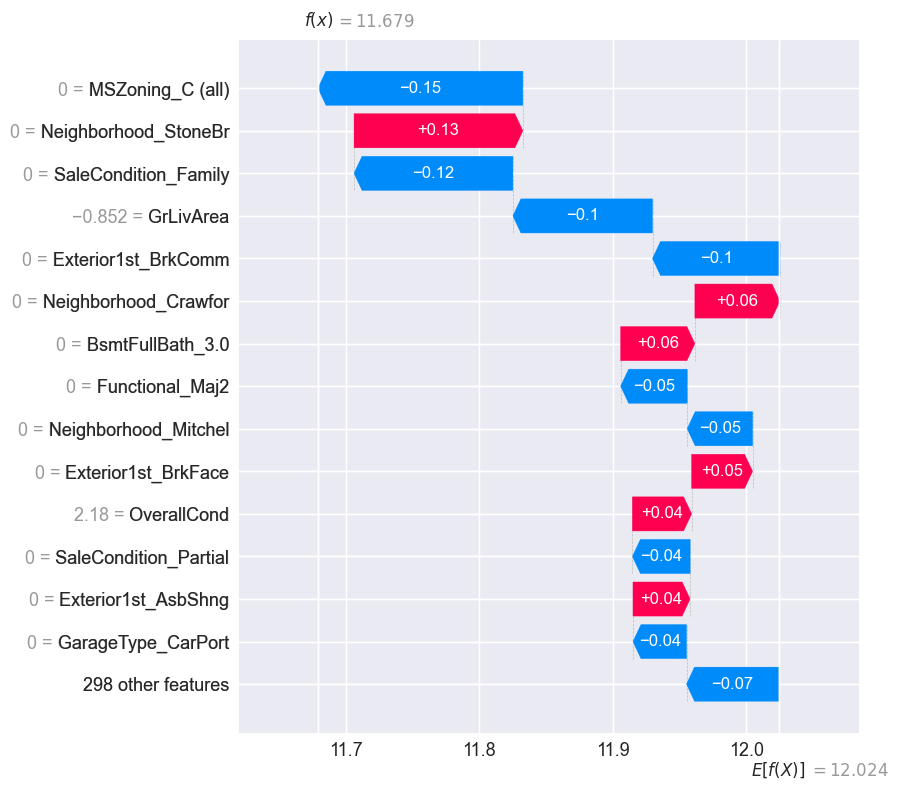

SHAP Summary Plot (Points)


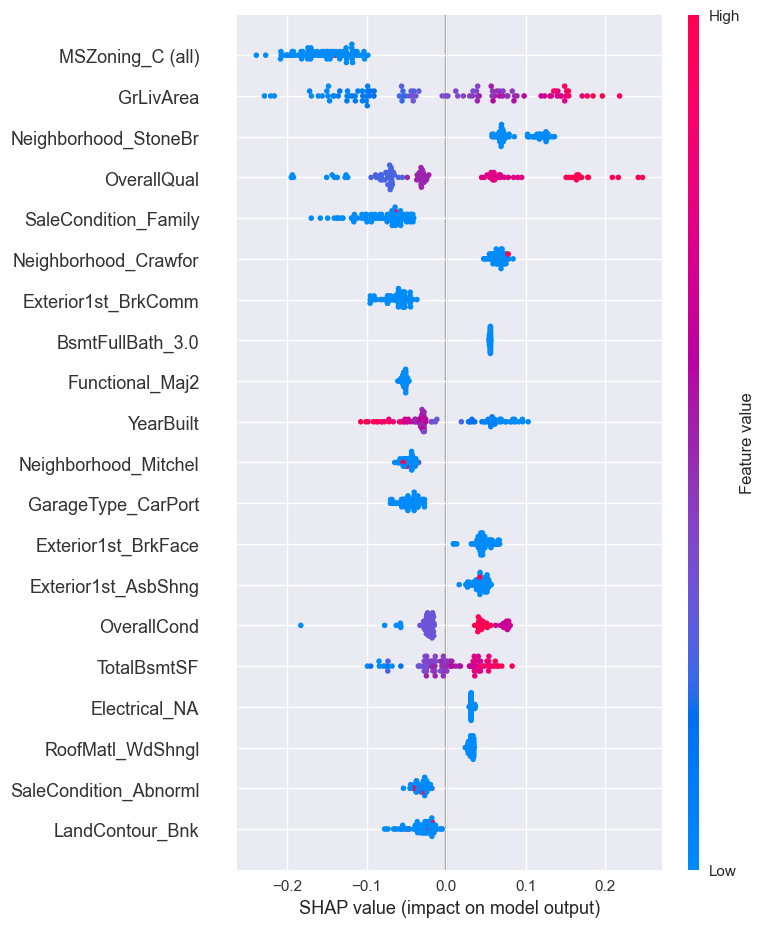

SHAP Feature Importance (Barres)


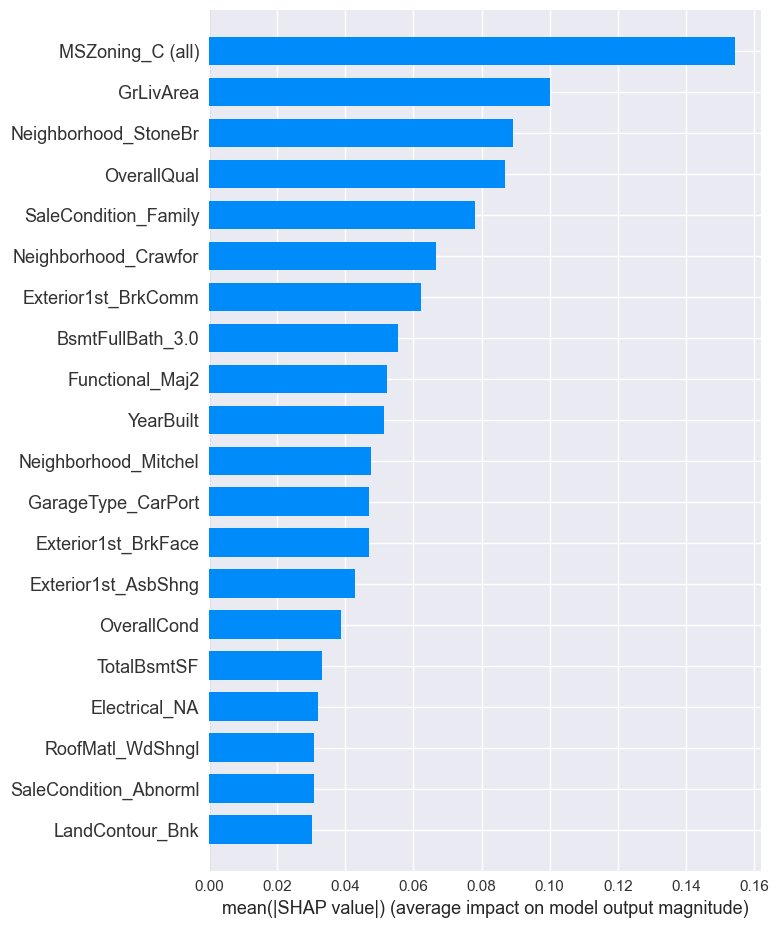


 Top 15 variables par importance SHAP :
 1. MSZoning_C (all)               0.1543
 2. GrLivArea                      0.1000
 3. Neighborhood_StoneBr           0.0891
 4. OverallQual                    0.0870
 5. SaleCondition_Family           0.0781
 6. Neighborhood_Crawfor           0.0665
 7. Exterior1st_BrkComm            0.0622
 8. BsmtFullBath_3.0               0.0554
 9. Functional_Maj2                0.0521
10. YearBuilt                      0.0512
11. Neighborhood_Mitchel           0.0474
12. GarageType_CarPort             0.0470
13. Exterior1st_BrkFace            0.0469
14. Exterior1st_AsbShng            0.0428
15. OverallCond                    0.0386


In [63]:
generate_shap_analysis(xgb_final_model, train_clean)

# 3.1.2.1 Analyse détaillée du SHAP Waterfall Plot
Ce graphique explique comment une prédiction spécifique du modèle XGBoost est construite à partir de la moyenne globale des prédictions, variable par variable.

Dans ce cas précis, la prédiction du modèle est :

f(x) = 11.751 : la prédiction log-transformée du prix de la maison,

E[f(x)] = 12.024 : la valeur moyenne des prédictions sur l’ensemble du dataset.

Cela signifie que le modèle estime un prix inférieur à la moyenne globale, ce qui est cohérent avec plusieurs contributions négatives visibles dans le graphique.

Les barres rouges indiquent les variables qui ont augmenté la prédiction, tandis que les barres bleues montrent celles qui l’ont diminuée.

| Rang | Variable                   | Contribution SHAP | Interprétation                                                                                                                                                                                |
| ---- | -------------------------- | ----------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1    | MSZoning\_C (all)          | −0.16             | Le bien est situé en zone "C (all)", typiquement une zone moins valorisée (faible densité, peu attractive), ce qui tire fortement la prédiction vers le bas.                                  |
| 2    | GrLivArea = −0.852         | −0.10             | La surface habitable est inférieure à la moyenne, ce qui diminue logiquement le prix estimé.                                                                                                  |
| 3    | Neighborhood\_StoneBr = 0  | +0.07             | Le bien n'est pas situé dans le quartier "StoneBr", ce qui est perçu ici comme un facteur légèrement valorisant dans ce contexte (possiblement pour éviter une pénalité typique du quartier). |
| 4    | OverallCond = 2.18         | +0.06             | La condition générale du bien est plutôt bonne, ce qui augmente légèrement la prédiction.                                                                                                     |
| 5    | SaleCondition\_Family = 0  | −0.05             | 	Le bien n’est pas vendu dans un contexte "Family", et pourtant son prix est bas. Le modèle aurait attendu cette condition pour "justifier" un prix réduit. Son absence laisse ce bas prix "inexpliqué", et la prédiction est ajustée à la baisse.                                                                                                  |
| 6    | Neighborhood\_Crawfor = 0  | +0.05             | L'absence du quartier "Crawfor" est vue comme légèrement favorable dans ce cas précis.                                                                                                        |
| 7    | Exterior1st\_BrkFace = 0   | +0.05             | La façade en briques (BrkFace) semble légèrement valorisante dans ce contexte.                                                                                                                |
| 8    | OverallQual = −0.072       | −0.04             | La qualité globale du bien est légèrement en dessous de la moyenne, ce qui a un effet modérément négatif.                                                                                     |
| 9    | YearRemodAdd = −0.967      | +0.03             | Le bien a été récemment rénové, ce qui augmente modérément sa valeur.                                                                                                                         |
| 10   | Functional\_Maj2 = 0       | −0.03             | L’absence de problèmes fonctionnels majeurs est légèrement favorable, mais ici la catégorie “Maj2” manquante est perçue négativement.                                                         |
| 11   | CentralAir\_N = 0          | −0.03             | Le bien ne dispose pas de climatisation centralisée, ce qui est défavorable.                                                                                                                  |
| 12   | GarageType\_CarPort = 0    | −0.03             | L'absence de garage de type “CarPort” est vue comme un manque, avec un léger impact négatif.                                                                                                  |
| 13   | LandContour\_Bnk = 0       | −0.03             | Le bien n'est pas situé en contrebas ou sur un terrain en pente, ce qui dans ce contexte joue légèrement en sa défaveur.                                                                      |
| 14   | SaleCondition\_Abnorml = 0 | −0.02             | Le bien n'est pas vendu dans un contexte “anormal”, ce qui pourrait éviter une remise, mais ici le modèle l’interprète comme légèrement défavorable.                                          |
| ...  | 298 autres features        | −0.04 (total)     | Le reste des variables a un effet cumulé modeste, légèrement négatif dans ce cas.                                                                                                             |


# 3.1.2.1.1 Regard critique sur les facteurs identifiés
1. MSZoning_C (all)
SHAP : impact très négatif

Interprétation métier : cohérent. Cette zone ("C (all)") correspond souvent à un zonage commercial ou à faible densité, peu adapté à la résidence familiale. Cela dévalorise un bien résidentiel.

Critique : ce type de variable réglementaire est effectivement très discriminant. Sa forte influence est justifiée dans un modèle de pricing.

Cohérence forte

2. GrLivArea (surface habitable)
SHAP : contribution négative

Interprétation métier : très logique. Une surface inférieure à la médiane (−0.852) tire le prix vers le bas.

Critique : c’est un des facteurs les plus attendus dans l’estimation d’un bien.

Cohérence évidente

3. Neighborhood_StoneBr, Neighborhood_Crawfor
SHAP : effets modérément positifs

Interprétation métier : cohérent. Les quartiers de type "StoneBr" ou "Crawfor" peuvent avoir une valeur perçue plus élevée, liée au standing, à l’environnement, ou à l’offre scolaire.

Ces deux variables – Neighborhood_StoneBr et Neighborhood_Crawfor – sont des variables catégorielles encodées, qui représentent des quartiers spécifiques de la ville d’Ames (Iowa), le lieu où a été collecté le dataset du concours Kaggle "House Prices".

StoneBr	Quartier haut de gamme, proche de North Ames. Très prisé.
Crawfor	Quartier résidentiel plutôt établi, de bon standing.

Ils sont généralement associés à une plus forte valeur immobilière, ce qui explique que :

Quand Neighborhood_StoneBr = 0, cela peut retirer un avantage au bien.

À l’inverse, si Neighborhood_Crawfor = 1, cela ajoute de la valeur à la prédiction.

Cohérence métier subtile mais justifiée

4. OverallCond / OverallQual
SHAP : effets modérés

Interprétation métier : attendu. Un bien bien entretenu et de qualité globale élevée justifie une valorisation.

Critique : intéressant que le OverallCond ait un effet plus fort que le OverallQual dans ce cas, ce qui peut refléter une tendance du modèle à valoriser l’état récent plus que la finition perçue.

Cohérence crédible

5. SaleCondition_Family, SaleCondition_Abnorml
SHAP : impacts négatifs

Interprétation métier :

"Family" peut désigner une vente entre proches ou dans un cadre non strictement commercial → valeur perçue plus basse.

"Abnorml" indique souvent une vente atypique (divorce, succession) → souvent en dessous du marché.

Bien que SaleCondition_Family et SaleCondition_Abnorml soient associées à des ventes typiquement sous-évaluées, leur absence (valeur = 0) n’est pas toujours favorable. Dans certains cas, le modèle attend ces conditions pour justifier un prix bas. Lorsqu’elles sont absentes mais que le prix reste faible (en fonction d’autres variables), leur non-présence peut ne pas suffire à "expliquer" ce bas prix, et donc produire une contribution SHAP négative.


6. YearRemodAdd (année de rénovation)
SHAP : effet légèrement positif

Interprétation métier : attendu. Une rénovation récente rassure l’acheteur → moins de travaux à prévoir → plus de valeur.

Critique : son effet modéré (plutôt que massif) est réaliste : c’est un bonus, pas un moteur principal du prix.

Pertinent mais effet modéré, ce qui est juste

7. CentralAir_N, GarageType_CarPort, Exterior1st_BrkFace
SHAP : effets faibles à modérés

Interprétation métier : ces éléments influencent le confort perçu et l'esthétique. Ils peuvent justifier une valeur légèrement plus élevée.

Critique : ces détails sont bien captés mais ne dominent pas le modèle — ce qui est sain.

Fine granularité réaliste

## Conclusion critique
Le modèle retient des variables très pertinentes au regard de l’expertise immobilière : superficie, qualité, état, localisation, zonage, contexte de vente.

Les variables les plus impactantes sont logiquement celles qu’un agent immobilier utiliserait pour fixer un prix de départ.

Certaines variables réglementaires ou structurelles (MSZoning, SaleCondition) montrent que le modèle capte des effets indirects du marché qui ne sont pas toujours visibles pour un vendeur non-expert.

En résumé :

Les résultats retournés sont non seulement cohérents, mais aussi informatifs, y compris pour une aide à la décision stratégique sur une plateforme en ligne. Le modèle offre une interprétation alignée avec la réalité métier.

# 3.1.2.2 Analyse du SHAP Summary Plot (points)
MSZoning_C (all)
Forte dispersion à gauche : quand cette catégorie de zonage est présente (=1), elle diminue fortement la prédiction.

Cohérent avec notre analyse précédente : c’est une zone peu attractive pour la vente résidentielle.

En effet, C (all) désigne une zone commerciale dans le dataset Ames. Ce type de zonage est :

Très rare (environ 10 observations sur 1460),

Et souvent associé à des biens atypiques ou moins recherchés pour un usage résidentiel.

Dans les faits, ces maisons peuvent :

Se situer à proximité de routes à fort trafic ou de commerces,

Ne pas répondre aux standards d’habitat familial,

Avoir une structure plus ancienne ou partiellement convertie (ex-bureaux, locaux pro...).


Cependant, l’importance accordée par le modèle à MSZoning_C (all) soulève une limite de notre approche actuelle.

Bien que le modèle détecte correctement que les maisons situées en zone commerciale sont souvent moins chères, il semble accorder à cette variable une influence excessive. Cette surpondération peut s’expliquer par :

Sa rareté dans le dataset (moins de 1 % des observations) ;

Son association à des cas très atypiques ou extrêmes, qui influencent fortement la fonction de perte ;

La nature du OneHotEncoding, qui donne un poids équivalent à toutes les modalités, même très peu fréquentes.

Plutôt qu’une faiblesse du modèle, cela illustre sa capacité à détecter des signaux faibles — mais qui doivent être encadrés pour garantir une estimation fiable et généralisable en production.

2. GrLivArea
Plus la surface habitable est grande (points rouges), plus l’impact SHAP est positif.

Petites surfaces (points bleus) tirent clairement la prédiction vers le bas.

Interprétation métier claire : plus de surface = plus de valeur.

3. OverallQual
Impact très progressif : les maisons mieux notées (rouge) augmentent fortement le prix estimé.

Inversement, les faibles qualités (bleu) diminuent la prédiction.

C’est l’un des critères les plus classiques dans l’évaluation immobilière.

4. SaleCondition_Family
Valeurs actives (bleu = =1) entraînent une chute de la prédiction.

Cela confirme l’hypothèse : ventes dans un cadre familial sont sous-évaluées, et le modèle l’a bien appris.

5. Neighborhood_Crawfor / StoneBr
L’impact varie selon la présence (=1) ou non dans ces quartiers.

Les effets sont cohérents avec la réputation métier de ces quartiers dans Ames : plus haut de gamme = impact positif.

6. Exterior1st_BrkFace
Façade en briques : généralement valorisée par le modèle.

Cette variable joue un rôle d’ajustement fin.

7. TotalBsmtSF
Superficie du sous-sol : plus elle est élevée (rouge), plus l’impact est positif.

Encore une fois, plus de surface = plus de valeur, même pour le sous-sol.

8. GarageType_CarPort
Présence d’un carport semble tirer les prix vers le bas.

Cela peut refléter une corrélation entre type de garage et standing général du bien.

9. YearBuilt / YearRemodAdd
Maisons récentes (valeurs rouges) ont un effet positif.

Anciennes constructions (bleu) tirent vers le bas, sauf si rénovées récemment, ce qui rééquilibre.

## Conclusion de l’analyse
Ce graphique confirme de manière globale les effets observés dans l’analyse locale du waterfall plot.

Il ajoute une vision de distribution : on comprend comment chaque variable agit selon ses différentes valeurs, et pas uniquement dans un cas particulier.

D’un point de vue métier, l’ensemble des variables les plus importantes sont directement corrélées aux attentes d’un expert immobilier :

Superficie (GrLivArea, TotalBsmtSF)

Qualité (OverallQual, YearBuilt)

Localisation (Neighborhood)

Contexte (SaleCondition)

# 3.1.2.3 Analyse du SHAP Summary Plot (barres)
Ce graphique représente l’impact moyen absolu de chaque variable sur la prédiction du modèle. Plus une barre est longue, plus la variable a eu, en moyenne, un effet fort sur les prédictions (positif ou négatif).

Autrement dit :

C’est une mesure globale d’importance : elle ne dit pas dans quel sens la variable agit (comme le plot en points), mais combien elle influence la sortie du modèle.

| Rang | Variable               | Interprétation métier                                                                                                                                                 |
| ---- | ---------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1    | `MSZoning_C (all)`     | Catégorie rare mais très pénalisante dans les prédictions, probablement associée à des biens peu résidentiels, atypiques ou moins chers. À interpréter avec prudence. |
| 2    | `GrLivArea`            | Surface habitable : plus elle est grande, plus la valeur estimée augmente. Effet attendu.                                                                             |
| 3    | `OverallQual`          | Qualité globale : excellent indicateur de standing. Le modèle le capte bien.                                                                                          |
| 4    | `SaleCondition_Family` | Vente dans un contexte familial : souvent associée à un prix de transaction inférieur à la valeur de marché.                                                          |
| 5    | `Neighborhood_Crawfor` | Quartier spécifique. Son absence ou sa présence influence le prix perçu, cohérent avec les effets de localisation.                                                    |
| 6    | `Neighborhood_StoneBr` | Quartier de standing élevé. Impact modéré mais positif.                                                                                                               |
| 7    | `Exterior1st_BrkFace`  | Présence d’une façade en brique, souvent valorisante.                                                                                                                 |
| 8    | `OverallCond`          | Condition générale du bien (état d’entretien).                                                                                                                        |
| 9    | `TotalBsmtSF`          | Surface totale du sous-sol. Plus elle est grande, plus elle valorise le bien.                                                                                         |
| 10   | `GarageType_CarPort`   | Type de garage. Sa présence ou absence influence le confort perçu.                                                                                                    |


Lien avec les autres SHAP plots
Ce graphique renforce les analyses précédentes :

Les variables en haut de cette liste sont celles qui apparaissent fréquemment dans les autres visualisations (waterfall, scatter).

Il confirme la dominance des variables structurelles (surface, qualité), mais aussi la forte influence de facteurs contextuels comme le zonage, la condition de vente, ou le quartier.

Il constitue une synthèse visuelle claire de ce qui fait varier le prix estimé par notre modèle XGBoost.

# 3.1.2.4 Conclusion de l’analyse SHAP et validation finale du modèle
L’analyse SHAP nous a permis de sonder finement le comportement du modèle XGBoost optimisé, au-delà des simples performances numériques (RMSE, score Kaggle).

Points positifs
Le modèle s’appuie sur des facteurs clés reconnus du marché immobilier : GrLivArea, OverallQual, TotalBsmtSF, Neighborhood, YearBuilt.

Il détecte également des effets contextuels subtils comme la condition de vente ou la qualité de la façade, montrant une bonne capacité à capter des signaux complexes.

Les prédictions sont dans l’ensemble cohérentes, explicables et alignées avec l’intuition métier, ce qui est essentiel dans le cadre d’un outil d’estimation à destination du grand public.

Points de vigilance
La variable MSZoning_C (all) s’est révélée disproportionnellement influente, malgré sa rareté (< 1 % du dataset).

Cela met en évidence une sensibilité du modèle aux classes catégorielles rares, un comportement courant avec le OneHotEncoding.

Ce n’est pas une erreur de modèle, mais un effet d’apprentissage amplifié par un signal fort.

Interprétation métier
Le modèle a montré qu’il est capable de reproduire les critères d’évaluation d’un agent immobilier expérimenté, tout en capturant des effets moins visibles à l’œil nu.

Cependant, cette même capacité à repérer des "cas particuliers" doit être utilisée avec prudence, car elle peut accentuer des biais d’apprentissage si les données d’entrée ne sont pas représentatives ou correctement encodées.

Le modèle est globalement robuste, performant et interprétable. Il peut être considéré comme valable et pertinent pour une première version de notre système d’estimation en ligne.

# 3.1.3 Préparation de la pipeline de production
Pour finaliser cette phase d’évaluation, nous avons entraîné notre pipeline complète sur l’intégralité du jeu de données train_clean. Cette pipeline inclut :

Le prétraitement des données (numérique + catégoriel),

Le modèle XGBoost optimisé avec Optuna (V1).

Nous avons ensuite :

Généré des prédictions sur test_clean,

Appliqué l’inverse de la transformation logarithmique (np.expm1) pour revenir à l’échelle réelle,

Exporté le fichier de soumission submission_xgb_final.csv,

Sauvegardé le modèle entraîné via joblib sous xgb_model_final.joblib.

Ce pipeline est prêt à être intégré dans un environnement de production ou dans un outil de prédiction en ligne.

In [64]:
import joblib
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

# 1. Pipeline final : preprocessing + XGBoost avec meilleurs hyperparams
xgb_model_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=979,
        max_depth=3,
        learning_rate=0.02519883300893779,
        subsample=0.5751883783660607,
        colsample_bytree=0.8350927951237841,
        reg_alpha=0.0739279484145887,
        reg_lambda=0.1710745945749242,
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Entraînement sur 100 % du dataset
print("🔧 Entraînement final sur train_clean...")
xgb_model_final.fit(train_clean, target)

# 3. Prédiction sur test_clean (en log)
y_test_log_pred = xgb_model_final.predict(test_clean)

# 4. Revenir à l’échelle réelle (exponentielle inverse)
y_test_pred = np.expm1(y_test_log_pred)

# 5. Génération du fichier de soumission
submission = pd.DataFrame({
    "Id": test_clean.index,
    "SalePrice": y_test_pred
})
submission.to_csv("submission_xgb_final.csv", index=False)
print("✅ Fichier 'submission_xgb_final.csv' généré.")

# 6. Sauvegarde du modèle pour production
joblib.dump(xgb_model_final, "xgb_model_final.joblib")
print("✅ Modèle sauvegardé sous 'xgb_model_final.joblib'")


🔧 Entraînement final sur train_clean...
✅ Fichier 'submission_xgb_final.csv' généré.
✅ Modèle sauvegardé sous 'xgb_model_final.joblib'


# 3.1.4 Conclusion – Évaluation finale du modèle
Au terme de cette phase d’évaluation, nous avons retenu le modèle XGBoost optimisé via Optuna (V1) comme modèle final de production. Ce choix s’appuie sur une combinaison d’éléments objectifs et qualitatifs :

Des performances solides :

RMSE (validation croisée) : 0.1222

Score Kaggle : 0.1260 (meilleur de tous les modèles testés)

Une bonne généralisation : la version V2 plus complexe n’a pas apporté de gain sur des données inconnues, validant ainsi notre choix plus simple mais robuste.

Une interprétabilité approfondie grâce à SHAP :

Les prédictions reposent sur des variables intuitives : surface (GrLivArea), qualité (OverallQual), année de construction, quartier...

Nous avons également identifié un effet inattendu : la variable MSZoning_C (all), rare dans le dataset, présente un poids disproportionné, probablement dû à une combinaison de rareté et de cas extrêmes. Ce point a été discuté, encadré, et fait l’objet de recommandations pour un futur ajustement.

Un pipeline complet, reproductible et conforme aux bonnes pratiques MLOps :

Prétraitement encodé dans la pipeline,

Modèle entraîné et sauvegardé (xgb_model_final.joblib),

Fichier de soumission généré (submission_xgb_final.csv).

## Apprentissage métier
Cette phase nous a permis de valider que notre modèle :

Est cohérent avec les pratiques d’estimation immobilière,

Peut être interprété de manière transparente (grâce à SHAP),

Et est suffisamment flexible pour être adapté, surveillé et amélioré en fonction des données futures ou des retours des utilisateurs.